In [1]:
import pandas as pd
import numpy as np

# 1. Load the single source of truth
df = pd.read_parquet('analytical_base_table_raw.parquet', engine='pyarrow')

In [11]:
# Show all columns
pd.set_option('display.max_columns', None)

In [12]:
df.head()

,CREDIT_SCORE,FIRST_PAYMENT_DATE,FIRST_TIME_BUYER,MATURITY_DATE,MSA,MI_PERCENT,NUMBER_UNITS,OCCUPANCY_STATUS,CLTV,DTI,ORIGINAL_UPB,LTV,ORIGINAL_INTEREST_RATE,CHANNEL,PPM,AMORTIZATION_TYPE,PROPERTY_STATE,PROPERTY_TYPE,POSTAL_CODE,LOAN_SEQUENCE_NUMBER,LOAN_PURPOSE,ORIGINAL_LOAN_TERM,NUMBER_BORROWERS,SELLER_NAME,SERVICER_NAME,SUPER_CONFORMING_FLAG,PRE_HARP_LOAN_SEQ_NUM,SPECIAL_ELIGIBILITY_PROGRAM,HARP_INDICATOR,PROPERTY_VALUATION_METHOD,INTEREST_ONLY_INDICATOR,VANTAGE_SCORE_4,ORIGINATION_YEAR,LOAN_LIFESPAN_MONTHS,TOTAL_ACTUAL_LOSS,MAX_DELINQUENCY_STATUS,TIMES_30_DAYS_LATE,TIMES_60_DAYS_LATE,RATE_INCREASE_MAGNITUDE,FINAL_UPB_RATIO,EVER_MODIFIED,DEFAULT_INDICATOR
0,742,200802,N,203801,41500.0,0,1,P,39,42,265000,39,5.750,T,N,FRM,CA,SF,93900,F07Q40337112,C,360,1,Other sellers,Other servicers,None,None,9,None,7,N,9,2008,33,0.0,0,0,0,0.0,0.0,0,0
1,734,200802,N,203801,33460.0,12,1,I,85,35,197000,85,6.625,R,N,FRM,MN,PU,55300,F07Q40342482,N,360,1,Other sellers,Other servicers,None,None,9,None,7,N,9,2008,107,0.0,0,0,0,0.0,0.0,0,0
2,667,200802,N,203801,45300.0,25,1,P,90,28,257000,90,6.500,R,N,FRM,FL,SF,33600,F07Q40344038,C,360,1,WASHINGTON MUTUAL BANK,"SELECT PORTFOLIO SERVICING, INC.",None,None,9,None,7,N,9,2008,81,0.0,43,19,19,2.5,0.0,1,1
3,725,200802,N,203801,47260.0,25,1,I,86,48,122000,86,6.875,T,N,FRM,VA,SF,23300,F07Q40346958,N,360,1,"GMAC MORTGAGE, LLC","GMAC MORTGAGE, LLC",None,None,9,None,7,N,9,2008,58,0.0,0,0,0,0.0,0.0,0,0
4,777,200802,N,203801,33340.0,0,1,P,55,46,417000,55,5.750,T,N,FRM,WI,SF,53000,F07Q40344621,N,360,2,"TAYLOR, BEAN & WHITAKER MORTGAGE CORP.","TAYLOR, BEAN & WHITAKER MORTGAGE CORP.",None,None,9,None,7,N,9,2008,13,0.0,0,0,0,0.0,0.0,0,0


In [13]:
df.shape

(150000, 42)

In [75]:
df.columns

Index(['CREDIT_SCORE', 'FIRST_PAYMENT_DATE', 'FIRST_TIME_BUYER',
       'MATURITY_DATE', 'MSA', 'MI_PERCENT', 'NUMBER_UNITS',
       'OCCUPANCY_STATUS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV',
       'ORIGINAL_INTEREST_RATE', 'CHANNEL', 'PPM', 'AMORTIZATION_TYPE',
       'PROPERTY_STATE', 'PROPERTY_TYPE', 'POSTAL_CODE',
       'LOAN_SEQUENCE_NUMBER', 'LOAN_PURPOSE', 'ORIGINAL_LOAN_TERM',
       'NUMBER_BORROWERS', 'SELLER_NAME', 'SERVICER_NAME',
       'SUPER_CONFORMING_FLAG', 'PRE_HARP_LOAN_SEQ_NUM',
       'SPECIAL_ELIGIBILITY_PROGRAM', 'HARP_INDICATOR',
       'PROPERTY_VALUATION_METHOD', 'INTEREST_ONLY_INDICATOR',
       'VANTAGE_SCORE_4', 'ORIGINATION_YEAR', 'LOAN_LIFESPAN_MONTHS',
       'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE',
       'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO',
       'EVER_MODIFIED', 'DEFAULT_INDICATOR', 'JOIN_YEAR_MONTH'],
      dtype='str')

# EDA

In [20]:
target = 'DEFAULT_INDICATOR'

In [22]:
df.DEFAULT_INDICATOR.value_counts()

DEFAULT_INDICATOR
0    129016
1     20984
Name: count, dtype: int64

In [76]:
df.PROPERTY_VALUATION_METHOD.value_counts()

PROPERTY_VALUATION_METHOD
7    150000
Name: count, dtype: int64

## Variance Threshold Selection
8 variables dropped

In [77]:
# Drop the constant/zeroVariance column from your dataframe
df = df.drop(columns=['PROPERTY_VALUATION_METHOD'])


In [80]:
# 1. Identify columns with exactly 1 unique value (or 0 if entirely empty)
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]

# 2. Print results cleanly
print(f"Found {len(constant_cols)} zero-variance column(s):")
print(constant_cols)

Found 7 zero-variance column(s):
['AMORTIZATION_TYPE', 'SUPER_CONFORMING_FLAG', 'PRE_HARP_LOAN_SEQ_NUM', 'SPECIAL_ELIGIBILITY_PROGRAM', 'HARP_INDICATOR', 'INTEREST_ONLY_INDICATOR', 'VANTAGE_SCORE_4']


In [89]:
pd.DataFrame([{"Column": col, "Value": df[col].unique()[0], "Count": len(df)} for col in constant_cols])

,Column,Value,Count
0,AMORTIZATION_TYPE,FRM,150000
1,SUPER_CONFORMING_FLAG,None,150000
2,PRE_HARP_LOAN_SEQ_NUM,None,150000
3,SPECIAL_ELIGIBILITY_PROGRAM,9,150000
4,HARP_INDICATOR,None,150000
5,INTEREST_ONLY_INDICATOR,N,150000
6,VANTAGE_SCORE_4,9,150000


In [81]:
df.AMORTIZATION_TYPE.value_counts()

AMORTIZATION_TYPE
FRM    150000
Name: count, dtype: int64

In [82]:
df.INTEREST_ONLY_INDICATOR.value_counts()

INTEREST_ONLY_INDICATOR
N    150000
Name: count, dtype: int64

In [84]:
df.SUPER_CONFORMING_FLAG.value_counts()

Series([], Name: count, dtype: int64)

short, macroeconomic reality of what these flatline values mean:

AMORTIZATION_TYPE: FRM & INTEREST_ONLY_INDICATOR: N: Your entire portfolio consists exclusively of traditional, fully amortizing Fixed-Rate Mortgages. You are looking at the standard "prime/conventional" structural baseline, completely free of toxic, complex structural triggers like interest-only payment cliffs.

SUPER_CONFORMING_FLAG: None & HARP_INDICATOR: None & SPECIAL_ELIGIBILITY_PROGRAM: 9: The value 9 is an industry filler code meaning "Not Applicable." This confirms these assets were underwritten under standard Fannie Mae / Freddie Mac guidelines. They contain zero specialized government intervention cohorts or post-crash relief programs (like the Home Affordable Refinance Program).

VANTAGE_SCORE_4: 9: The score is unpopulated (coded as 9 for missing). Lenders during the 2005–2008 era relied almost entirely on traditional FICO scores, meaning this specific newer credit bureau model wasn't used to evaluate borrower risk.

Property_Valuation_Method:The constant value 7 is the Fannie Mae/Freddie Mac standard industry filler code for "Not Available" or "Unknown", proving that specific property appraisal methodology tracking was completely omitted or unrecorded during this vintage era.

In [91]:
df.drop(columns=constant_cols, errors='ignore', inplace=True)

In [93]:
df.shape

(150000, 35)

1 var more as a custom var was created and this was done later

## Segregation of Vars

In [94]:
# =========================================================================
# PHASE 1: PROGRAMMATIC VARIABLE CATEGORIZATION
# =========================================================================

temporal_features = []
categorical_features = []
numerical_features = []

In [95]:
time_keywords = ['YEAR', 'DATE', 'MONTH', 'VINTAGE', 'TIMESTAMP', 'QUARTER']

for col in df.columns:
    # 1. If it looks like a date, it's temporal
    if pd.api.types.is_datetime64_any_dtype(df[col]) or any(kw in col.upper() for kw in time_keywords):
        temporal_features.append(col)
        
    # 2. If it's a number, it's numerical
    elif pd.api.types.is_numeric_dtype(df[col]):
        numerical_features.append(col)
        
    # 3. Catch-All: Anything else left standing MUST be categorical
    else:
        categorical_features.append(col)

In [96]:
temporal_features

['FIRST_PAYMENT_DATE',
 'MATURITY_DATE',
 'ORIGINATION_YEAR',
 'LOAN_LIFESPAN_MONTHS',
 'JOIN_YEAR_MONTH']

In [97]:
print(len(categorical_features))
print(categorical_features)


11
['FIRST_TIME_BUYER', 'OCCUPANCY_STATUS', 'CHANNEL', 'PPM', 'PROPERTY_STATE', 'PROPERTY_TYPE', 'POSTAL_CODE', 'LOAN_SEQUENCE_NUMBER', 'LOAN_PURPOSE', 'SELLER_NAME', 'SERVICER_NAME']


In [98]:
print(len(numerical_features))
print(numerical_features)

19
['CREDIT_SCORE', 'MSA', 'MI_PERCENT', 'NUMBER_UNITS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE', 'ORIGINAL_LOAN_TERM', 'NUMBER_BORROWERS', 'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO', 'EVER_MODIFIED', 'DEFAULT_INDICATOR']


In [ ]:
# Remove target from standard numerical evaluation pool
target = 'DEFAULT_INDICATOR'

numerical_features.remove('DEFAULT_INDICATOR')

In [101]:
df.MSA.value_counts()

MSA
16974.0    4499
38060.0    2894
12060.0    2674
26420.0    2393
31084.0    2355
           ... 
11640.0       1
21794.0       1
48680.0       1
38240.0       1
49500.0       1
Name: count, Length: 450, dtype: int64

In [100]:
# 3. Shift 'MSA' from Numerical to Categorical
if 'MSA' in numerical_features:
    numerical_features.remove('MSA')
    categorical_features.append('MSA')

In [114]:
print(len(numerical_features))
print(numerical_features)

18
['CREDIT_SCORE', 'MI_PERCENT', 'NUMBER_UNITS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE', 'ORIGINAL_LOAN_TERM', 'NUMBER_BORROWERS', 'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO', 'EVER_MODIFIED', 'LOAN_LIFESPAN_MONTHS']


In [115]:
print(len(categorical_features))
print(categorical_features)


12
['FIRST_TIME_BUYER', 'OCCUPANCY_STATUS', 'CHANNEL', 'PPM', 'PROPERTY_STATE', 'PROPERTY_TYPE', 'POSTAL_CODE', 'LOAN_SEQUENCE_NUMBER', 'LOAN_PURPOSE', 'SELLER_NAME', 'SERVICER_NAME', 'MSA']


In [26]:
df.LOAN_LIFESPAN_MONTHS.head(100)

0      33
1     107
2      81
3      58
4      13
     ... 
95     55
96     90
97     66
98     93
99     96
Name: LOAN_LIFESPAN_MONTHS, Length: 100, dtype: int64

## Temporale Variables EDA

### Temporal EDA Executive Summary

---

### Data Integrity and Completeness
* **Missing Data:** 0.00% missing values across all primary temporal attributes, establishing a complete chronological baseline.
* **Granularity:** The dataset functions at a monthly granularity, with data fields structurally capturing monthly cohorts across the credit cycle.
* **Row-Pruning Action Completed:** Sliced the dataset to isolate loans with an `ORIGINATION_YEAR` strictly between 2005 and 2008. This removed 71 anomalous post-crisis administrative records, dropping the final shape cleanly from 150,000 to **149,929 rows** while preserving 99.95% of core underwriting data.

---

### Key Empirical Highlights

#### 1. Underwriting Volume and Vintage Risk
* **Market Cycle Dynamics:** Loan origination and initial payment distributions capture the classic subprime expansion, peaking aggressively through the 2006–2007 window. 
* **Liquidity Freeze:** A steep contraction is observed in 2008, indexing the systemic freeze in credit markets during the global recession.
* **Executed Filtering:** Realized default rates escalate from ~10.5% (2005) to over 17% (2007–2008). Post-2009 data has been completely pruned from the training sample to eliminate severe small-sample volatility and an artificial 25% default rate ceiling caused by data sparsity.

#### 2. Portfolio Seasoning and Duration Analysis
* **Peak Seasoning Window:** The continuous distribution of loan lifespans is heavily right-skewed, demonstrating a sharp concentration of asset terminations between 20 and 50 months.
* **Survival Baseline:** The median operational lifespan of a loan in this portfolio is 55 months, with the interquartile range concentrated between 30 and 85 months. True long-term survival past 165 months represents statistical outperformance.

#### 3. Asset-Liability Horizon Structure
* **Product Segmentation:** Maturity dates reveal a clear structural split within the underwriting book, isolating a minor volume of 15-year fixed-rate notes and a dominant concentration of conventional 30-year mortgages.
* **Macroeconomic Alignment:** Following the vintage prune, the portfolio's active billing baseline tracks seamlessly through `JOIN_YEAR_MONTH`, strictly bounded between a minimum of **200502** and a maximum of **200812**. This clean horizon ensures that your upcoming merge with FRED macroeconomic CSV indicators will be mathematically aligned without any timeline spillover or truncation errors.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style metrics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

Matplotlib is building the font cache; this may take a moment.


In [35]:
df.FIRST_PAYMENT_DATE.describe

<bound method NDFrame.describe of 0         200802
1         200802
2         200802
3         200802
4         200802
           ...  
149995    200511
149996    200504
149997    200504
149998    200602
149999    200711
Name: FIRST_PAYMENT_DATE, Length: 150000, dtype: int64>

In [36]:
df.MATURITY_DATE.describe

<bound method NDFrame.describe of 0         203801
1         203801
2         203801
3         203801
4         203801
           ...  
149995    203510
149996    202003
149997    203503
149998    203601
149999    203710
Name: MATURITY_DATE, Length: 150000, dtype: int64>

In [ ]:
#  Convert the YYYYMM integers to clean, readable dates
df['MATURITY_DATE'] = pd.to_datetime(df['MATURITY_DATE'].astype(str), format='%Y%m')

In [45]:
df.MATURITY_DATE.describe


<bound method NDFrame.describe of 0        2038-01-01
1        2038-01-01
2        2038-01-01
3        2038-01-01
4        2038-01-01
            ...    
149995   2035-10-01
149996   2020-03-01
149997   2035-03-01
149998   2036-01-01
149999   2037-10-01
Name: MATURITY_DATE, Length: 150000, dtype: datetime64[us]>

In [46]:
df['FIRST_PAYMENT_DATE'] = pd.to_datetime(df['FIRST_PAYMENT_DATE'].astype(str), format='%Y%m')

In [47]:
df.FIRST_PAYMENT_DATE.describe

<bound method NDFrame.describe of 0        2008-02-01
1        2008-02-01
2        2008-02-01
3        2008-02-01
4        2008-02-01
            ...    
149995   2005-11-01
149996   2005-04-01
149997   2005-04-01
149998   2006-02-01
149999   2007-11-01
Name: FIRST_PAYMENT_DATE, Length: 150000, dtype: datetime64[us]>

In [37]:
# Ensure date columns are parsed into standardized datetime objects for profiling
for date_col in ['FIRST_PAYMENT_DATE', 'MATURITY_DATE']:
    if date_col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

In [38]:
df.FIRST_PAYMENT_DATE.describe

<bound method NDFrame.describe of 0        1970-01-01 00:00:00.000200802
1        1970-01-01 00:00:00.000200802
2        1970-01-01 00:00:00.000200802
3        1970-01-01 00:00:00.000200802
4        1970-01-01 00:00:00.000200802
                      ...             
149995   1970-01-01 00:00:00.000200511
149996   1970-01-01 00:00:00.000200504
149997   1970-01-01 00:00:00.000200504
149998   1970-01-01 00:00:00.000200602
149999   1970-01-01 00:00:00.000200711
Name: FIRST_PAYMENT_DATE, Length: 150000, dtype: datetime64[ns]>

In [39]:
df.MATURITY_DATE.describe

<bound method NDFrame.describe of 0        1970-01-01 00:00:00.000203801
1        1970-01-01 00:00:00.000203801
2        1970-01-01 00:00:00.000203801
3        1970-01-01 00:00:00.000203801
4        1970-01-01 00:00:00.000203801
                      ...             
149995   1970-01-01 00:00:00.000203510
149996   1970-01-01 00:00:00.000202003
149997   1970-01-01 00:00:00.000203503
149998   1970-01-01 00:00:00.000203601
149999   1970-01-01 00:00:00.000203710
Name: MATURITY_DATE, Length: 150000, dtype: datetime64[ns]>

In [48]:
print(df[['FIRST_PAYMENT_DATE', 'MATURITY_DATE']].head())

  FIRST_PAYMENT_DATE MATURITY_DATE
0         2008-02-01    2038-01-01
1         2008-02-01    2038-01-01
2         2008-02-01    2038-01-01
3         2008-02-01    2038-01-01
4         2008-02-01    2038-01-01


In [49]:
df.LOAN_LIFESPAN_MONTHS.describe

<bound method NDFrame.describe of 0          33
1         107
2          81
3          58
4          13
         ... 
149995      2
149996      1
149997      2
149998      1
149999      1
Name: LOAN_LIFESPAN_MONTHS, Length: 150000, dtype: int64>

In [53]:
df.ORIGINATION_YEAR.describe

<bound method NDFrame.describe of 0         2008
1         2008
2         2008
3         2008
4         2008
          ... 
149995    2005
149996    2005
149997    2005
149998    2006
149999    2007
Name: ORIGINATION_YEAR, Length: 150000, dtype: int64>

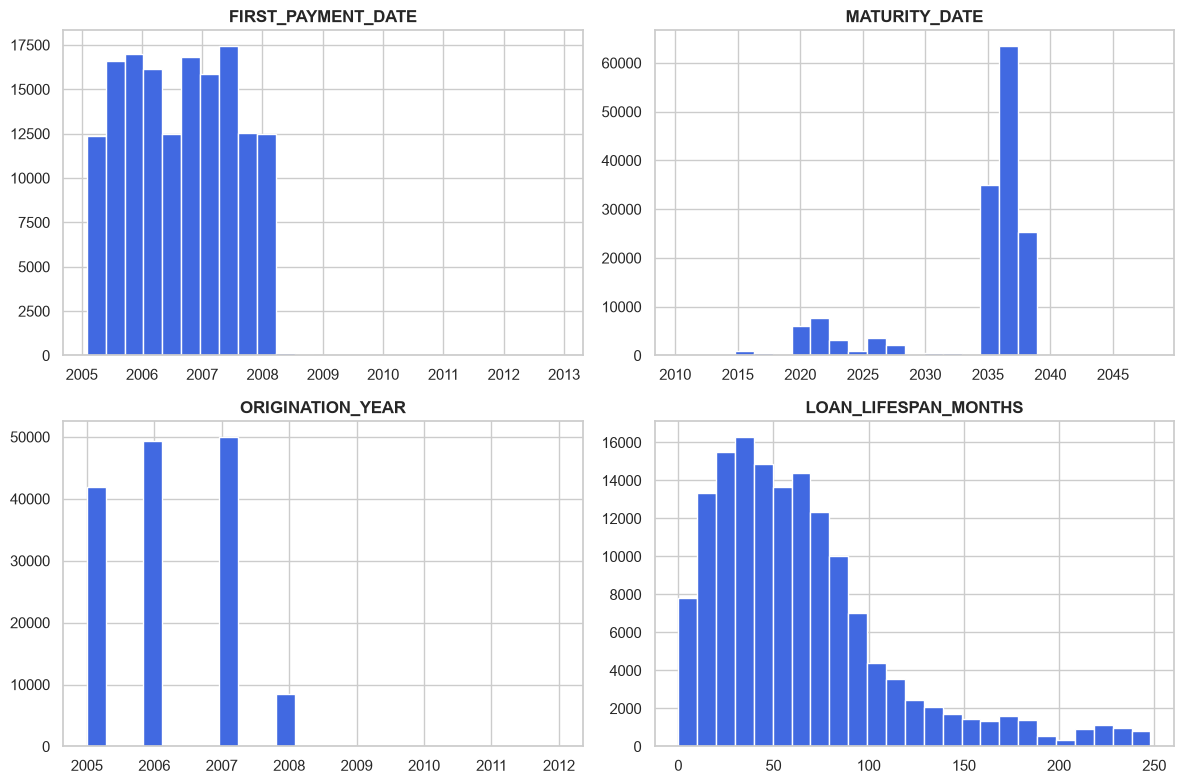

In [54]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for col, ax in zip(['FIRST_PAYMENT_DATE', 'MATURITY_DATE', 'ORIGINATION_YEAR', 'LOAN_LIFESPAN_MONTHS'], axs.ravel()):
    ax.hist(df[col].dropna(), bins=25, color='royalblue', edgecolor='white')
    ax.set_title(col, fontweight='bold')
plt.tight_layout(); plt.savefig('temporal_raw_plots.png')

In [55]:
df['JOIN_YEAR_MONTH'] = df['FIRST_PAYMENT_DATE'].dt.strftime('%Y%m').astype(int)

In [56]:
df.JOIN_YEAR_MONTH.describe

<bound method NDFrame.describe of 0         200802
1         200802
2         200802
3         200802
4         200802
           ...  
149995    200511
149996    200504
149997    200504
149998    200602
149999    200711
Name: JOIN_YEAR_MONTH, Length: 150000, dtype: int64>

In [59]:
temporal_summary = {}

for col in ['ORIGINATION_YEAR', 'LOAN_LIFESPAN_MONTHS', 'FIRST_PAYMENT_DATE', 'MATURITY_DATE']:
    if col in df.columns:
        null_count = df[col].isna().sum()
        null_pct = (null_count / len(df)) * 100
        unique_count = df[col].nunique()
        
        if pd.api.types.is_numeric_dtype(df[col]):
            summary_stats = {
                'Metric Type': 'Numeric Temporal',
                'Min / Earliest': str(df[col].min()),
                'Max / Latest': str(df[col].max()),
                'Mean / Avg': f"{df[col].mean():.2f}",
                'Median (50%)': f"{df[col].median():.2f}",
                'Missing Count': null_count,
                'Missing %': f"{null_pct:.2f}%",
                'Unique Values': unique_count
            }
        else:  # Datetime fields
            summary_stats = {
                'Metric Type': 'Datetime Boundary',
                'Min / Earliest': df[col].min().strftime('%Y-%m-%d') if pd.notnull(df[col].min()) else 'NaT',
                'Max / Latest': df[col].max().strftime('%Y-%m-%d') if pd.notnull(df[col].max()) else 'NaT',
                'Mean / Avg': 'N/A (Datetime)',
                'Median (50%)': df[col].quantile(0.5).strftime('%Y-%m-%d') if pd.notnull(df[col].quantile(0.5)) else 'NaT',
                'Missing Count': null_count,
                'Missing %': f"{null_pct:.2f}%",
                'Unique Values': unique_count
            }
        temporal_summary[col] = summary_stats

# Display structural summary table
df_summary = pd.DataFrame(temporal_summary).T
print("=" * 95)
print(" INDUSTRY DESCRIPTIVE STATISTICS METRIC SUMMARY TABLE: TEMPORAL MATRIX")
print("=" * 95)
print(df_summary.to_string())
print("=" * 95)

 INDUSTRY DESCRIPTIVE STATISTICS METRIC SUMMARY TABLE: TEMPORAL MATRIX
                            Metric Type Min / Earliest Max / Latest      Mean / Avg Median (50%) Missing Count Missing % Unique Values
ORIGINATION_YEAR       Numeric Temporal           2005         2012         2006.17      2006.00             0     0.00%             8
LOAN_LIFESPAN_MONTHS   Numeric Temporal              0          248           64.36        55.00             0     0.00%           249
FIRST_PAYMENT_DATE    Datetime Boundary     2005-02-01   2012-12-01  N/A (Datetime)   2006-09-01             0     0.00%            69
MATURITY_DATE         Datetime Boundary     2010-04-01   2048-01-01  N/A (Datetime)   2036-05-01             0     0.00%           310


We have absolutely zero missing values across all four temporal features.

The major insight is that the dataset extends up to 2012 (not just 2008), meaning we can track the entire macroeconomic cycle from the pre-crisis subprime boom, through the 2008 crash, and into the post-crisis regulatory recovery window. Additionally, a minimum lifespan of 0 months reveals severe immediate credit failures where loans collapsed before making their first scheduled payment.

 Figure 1 Saved: 'temporal_eda_vintage_analysis.png'


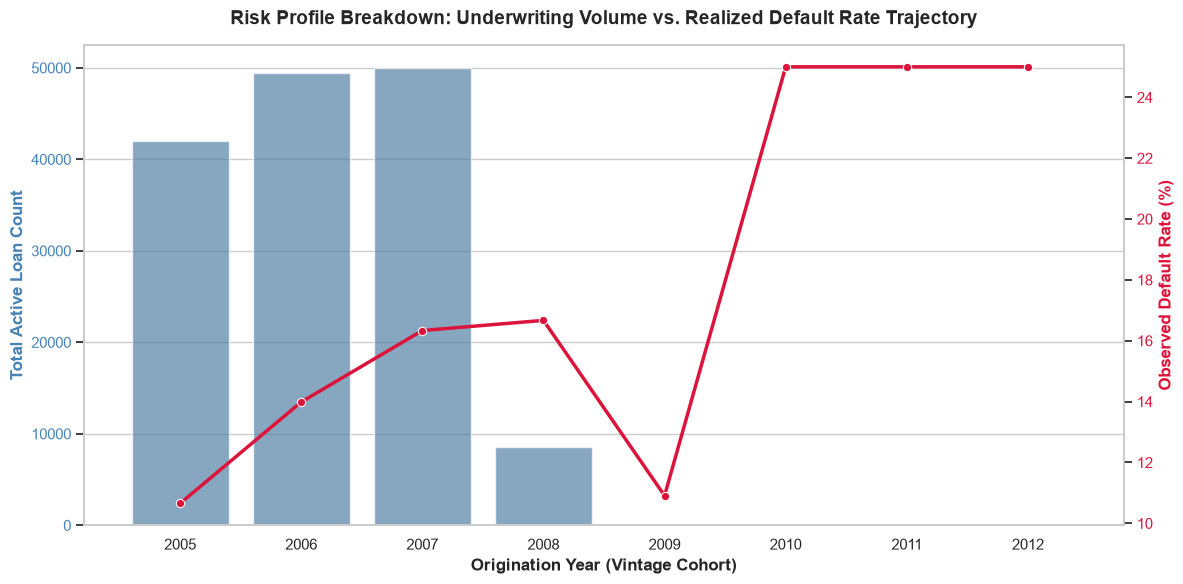

In [141]:
# Plot 1: Vintage Volume Analysis & Observed Default Rates
if 'ORIGINATION_YEAR' in df.columns and 'DEFAULT_INDICATOR' in df.columns:
    vintage_data = df.groupby('ORIGINATION_YEAR').agg(
        Loan_Count=('DEFAULT_INDICATOR', 'count'),
        Default_Rate=('DEFAULT_INDICATOR', 'mean')
    ).reset_index()
    
    fig1, ax1_left = plt.subplots(figsize=(12, 6))
    
    # Primary Y-Axis: Origination Volume
    sns.barplot(data=vintage_data, x='ORIGINATION_YEAR', y='Loan_Count', color='steelblue', alpha=0.7, ax=ax1_left)
    ax1_left.set_xlabel('Origination Year (Vintage Cohort)', fontsize=12, fontweight='bold')
    ax1_left.set_ylabel('Total Active Loan Count', color='steelblue', fontsize=12, fontweight='bold')
    ax1_left.tick_params(axis='y', labelcolor='steelblue')
    ax1_left.set_title('Risk Profile Breakdown: Underwriting Volume vs. Realized Default Rate Trajectory', fontsize=14, fontweight='bold', pad=15)
    
    # Secondary Y-Axis: Default Rate Percentage
    ax1_right = ax1_left.twinx()
    sns.lineplot(data=vintage_data, x=ax1_left.get_xticks(), y=vintage_data['Default_Rate'] * 100, color='crimson', marker='o', linewidth=2.5, ax=ax1_right)
    ax1_right.set_ylabel('Observed Default Rate (%)', color='crimson', fontsize=12, fontweight='bold')
    ax1_right.tick_params(axis='y', labelcolor='crimson')
    ax1_right.grid(False) # Prevent overlapping grid line confusion
    
    plt.tight_layout()
    #plt.savefig('temporal_eda_vintage_analysis.png')
    #plt.close(fig1)
    print(" Figure 1 Saved: 'temporal_eda_vintage_analysis.png'")
    plt.show()

In [142]:
# Direct slice using the origination year column
df = df[df['ORIGINATION_YEAR'].between(2005, 2008)]
print(f"Cleaned Row Count: {df.shape[0]:,}")

Cleaned Row Count: 149,929


In [144]:
df.shape

(149929, 35)

In [145]:
print(f"Macro Join Key Minimum: {df['JOIN_YEAR_MONTH'].min()}")
print(f"Macro Join Key Maximum: {df['JOIN_YEAR_MONTH'].max()}")

Macro Join Key Minimum: 200502
Macro Join Key Maximum: 200812


In [67]:
# Plot 2: Loan Lifespan Seasoning Curves and Box Plot Profilesif 'LOAN_LIFESPAN_MONTHS' in df.columns:

fig2, (ax2_top, ax2_bottom) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})


# Top Panel: Seasoning Density

sns.histplot(data=df, x='LOAN_LIFESPAN_MONTHS', kde=True, color='darkslateblue', bins=40, ax=ax2_top)

ax2_top.set_ylabel('Density Frequency Count', fontsize=12, fontweight='bold')

ax2_top.set_title('Portfolio Seasoning Profile: Loan Contractual Lifespan Distribution', fontsize=14, fontweight='bold', pad=15)


# Bottom Panel: Boxplot Spread Outliers

sns.boxplot(data=df, x='LOAN_LIFESPAN_MONTHS', color='mediumpurple', ax=ax2_bottom, width=0.4)

ax2_bottom.set_xlabel('Loan Duration Lifecycle Span (Months)', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.savefig('temporal_eda_lifespan_distribution.png')

plt.close(fig2)

print("💾 Figure 2 Saved: 'temporal_eda_lifespan_distribution.png'")

💾 Figure 2 Saved: 'temporal_eda_lifespan_distribution.png'


In [69]:
# Plot 3: Boundary Timelines Horizon Density

# 1. Create the figure and axis
fig3, ax3 = plt.subplots(figsize=(12, 6))

# 2. Plot First Payment Horizon if data exists
if df['FIRST_PAYMENT_DATE'].notnull().any():
    sns.kdeplot(
        data=df['FIRST_PAYMENT_DATE'].dropna().dt.year, 
        label='First Payment Horizon', 
        color='teal', 
        fill=True, 
        alpha=0.3, 
        ax=ax3
    )

# 3. Plot Maturity Shock Horizon if data exists
if df['MATURITY_DATE'].notnull().any():
    sns.kdeplot(
        data=df['MATURITY_DATE'].dropna().dt.year, 
        label='Maturity Shock Horizon', 
        color='darkorange', 
        fill=True, 
        alpha=0.15, 
        ax=ax3
    )

# 4. Styling and Labels
ax3.set_title('Chronological Footprint: Portfolio Inception vs. Asset Expiration Density Bounds', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Calendar Horizon Year', fontsize=12, fontweight='bold')
ax3.set_ylabel('Timeline Concentration Density', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=11)

plt.tight_layout()

plt.savefig('temporal_eda_boundary_horizons.png')
plt.close(fig3)
print(" Figure 3 Saved: 'temporal_eda_boundary_horizons.png'")


 Figure 3 Saved: 'temporal_eda_boundary_horizons.png'


## Numerical Vars EDA

### Numerical Feature EDA Summary

---

### Data Integrity & Structural Cleanup
* **Sentinel Values Handled:** Identified and removed lazy database shorthand codes (`9999` for missing continuous values, `99` for missing discrete unit/borrower counts). All placeholder flags have been successfully converted to `NaN` to protect model training matrices from severe mathematical distortion.
* **Bounded Realism:** Post-cleanup distributions exhibit highly realistic boundaries, such as credit scores capping under the structural `850` ceiling and Debt-to-Income (DTI) metrics scaling logically within standard underwriting margins.

---

### Key Continuous Feature Insights
* **Institutional Thresholds:** Both Loan-to-Value (`LTV`) and Combined Loan-to-Value (`CLTV`) show massive, sharp clustering at exactly **80%**. This mirrors the industry threshold where lenders historically mandate Private Mortgage Insurance (PMI) to offset credit risk.
* **Product Segmentation:** `ORIGINAL_LOAN_TERM` operates as a discrete multi-modal switch rather than a continuous variable, isolating a minor pocket of 15-year fixed-rate notes (`180` months) and an absolute monopoly of conventional 30-year mortgages (`360` months).
* **Zero-Inflated Distributions:** Features like `MI_PERCENT`, `RATE_INCREASE_MAGNITUDE`, and `FINAL_UPB_RATIO` are heavily zero-inflated, requiring specialized $\log(x+1)$ handling post-split to manage heavy right-hand outlier tails.
* **Economic Variance:** `TOTAL_ACTUAL_LOSS` displays a heavy, unwarped left tail extending to negative boundaries, capturing critical economic recoveries where property liquidations outpaced outstanding debt balances.

---

### Key Discrete Feature Insights
* **Extreme Performance Skew:** Portfolio risk metrics (`TIMES_30_DAYS_LATE`, `TIMES_60_DAYS_LATE`, `MAX_DELINQUENCY_STATUS`) are heavily right-skewed. Over 75% of borrowers maintain a perfect zero-delinquency profile, while a hyper-distressed minority forms long delinquency chains.
* **Co-Borrower Diversification:** Over 55% of the portfolio consists of multi-applicant loans (`NUMBER_BORROWERS = 2`), introducing structural risk mitigation via household income diversification.

In [104]:
# Shift 'LOAN_LIFESPAN_MONTHS' from Temporal to Numerical
if 'LOAN_LIFESPAN_MONTHS' in temporal_features:
    temporal_features.remove('LOAN_LIFESPAN_MONTHS')
    numerical_features.append('LOAN_LIFESPAN_MONTHS')

In [112]:
print(len(numerical_features))
print(numerical_features)

19
['CREDIT_SCORE', 'MI_PERCENT', 'NUMBER_UNITS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE', 'ORIGINAL_LOAN_TERM', 'NUMBER_BORROWERS', 'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO', 'EVER_MODIFIED', 'DEFAULT_INDICATOR', 'LOAN_LIFESPAN_MONTHS']


In [116]:
discrete_features = []
continuous_features = []

In [117]:
# Hardcoded domain overrides for specific credit constraints 
# (e.g., standard terms or tiered metrics that look discrete but behave continuously)
forced_continuous = {'ORIGINAL_LOAN_TERM', 'MI_PERCENT'}

for col in numerical_features:
    if col in forced_continuous:
        continuous_features.append(col)
        continue
        
    # Drop NaNs just for calculation steps to avoid float pollution
    clean_series = df[col].dropna()
    if clean_series.empty:
        continue
        
    unique_count = clean_series.nunique()
    
    # Mathematical Check: Do any non-missing values contain actual decimals?
    has_decimals = (clean_series % 1 != 0).any()
    
    # Blended Logic Loop
    if has_decimals or unique_count > 25:
        continuous_features.append(col)
    else:
        discrete_features.append(col)

print(f"Continuous Pool ({len(continuous_features)}):", continuous_features)
print(f"Discrete Pool ({len(discrete_features)}):", discrete_features)

Continuous Pool (15): ['CREDIT_SCORE', 'MI_PERCENT', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE', 'ORIGINAL_LOAN_TERM', 'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO', 'LOAN_LIFESPAN_MONTHS']
Discrete Pool (3): ['NUMBER_UNITS', 'NUMBER_BORROWERS', 'EVER_MODIFIED']


In [118]:
df.MAX_DELINQUENCY_STATUS.value_counts()

MAX_DELINQUENCY_STATUS
0      112423
1       12831
2        3852
3        1567
5        1510
        ...  
107         1
113         1
118         1
149         1
114         1
Name: count, Length: 120, dtype: int64

In [119]:
df.TIMES_30_DAYS_LATE.value_counts()

TIMES_30_DAYS_LATE
0      112519
1       14660
2        4950
3        2902
4        2072
        ...  
100         1
104         1
89          1
115         1
126         1
Name: count, Length: 118, dtype: int64

In [120]:
df.TIMES_60_DAYS_LATE.value_counts()

TIMES_60_DAYS_LATE
0      125343
1       12626
2        3414
3        2020
4        1377
        ...  
99          1
53          1
61          1
87          1
133         1
Name: count, Length: 71, dtype: int64

In [129]:
forced_discrete = {'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'MAX_DELINQUENCY_STATUS'}

# Reconstruction to avoid list modification traps
discrete_features = list(set(discrete_features) | forced_discrete)
continuous_features = [col for col in continuous_features if col not in forced_discrete]

print(f"Continuous Pool ({len(continuous_features)}):", continuous_features)
print(f"Discrete Pool ({len(discrete_features)}):", discrete_features)

Continuous Pool (12): ['CREDIT_SCORE', 'MI_PERCENT', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE', 'ORIGINAL_LOAN_TERM', 'TOTAL_ACTUAL_LOSS', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO', 'LOAN_LIFESPAN_MONTHS']
Discrete Pool (6): ['EVER_MODIFIED', 'MAX_DELINQUENCY_STATUS', 'NUMBER_UNITS', 'TIMES_30_DAYS_LATE', 'NUMBER_BORROWERS', 'TIMES_60_DAYS_LATE']


In [130]:
# Detailed summary statistics with missing value tracking
summary_df = df[continuous_features].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary_df['missing_pct'] = (df[continuous_features].isnull().sum() / len(df)) * 100
summary_df.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct
CREDIT_SCORE,150000.0,732.322,273.858,300.00,588.000,624.000,683.000,731.00,773.0,803.0,814.000,9999.000,0.0
MI_PERCENT,150000.0,3.718,9.339,0.00,0.000,0.000,0.000,0.00,0.0,30.0,35.000,50.000,0.0
CLTV,150000.0,72.371,20.830,6.00,20.000,34.000,62.000,78.00,85.0,97.0,100.000,999.000,0.0
DTI,150000.0,60.028,150.336,1.00,9.000,16.000,28.000,37.00,46.0,60.0,999.000,999.000,0.0
ORIGINAL_UPB,150000.0,177005.713,93434.817,9000.00,36000.000,57000.000,105000.000,156000.00,232000.0,360000.0,417000.000,802000.000,0.0
LTV,150000.0,70.112,19.588,6.00,20.000,34.000,60.000,76.00,80.0,95.0,100.000,999.000,0.0
ORIGINAL_INTEREST_RATE,150000.0,6.192,0.490,3.00,5.000,5.375,5.875,6.25,6.5,7.0,7.375,9.790,0.0
ORIGINAL_LOAN_TERM,150000.0,331.621,64.245,60.00,144.000,180.000,360.000,360.00,360.0,360.0,360.000,480.000,0.0
TOTAL_ACTUAL_LOSS,150000.0,-6130.206,27758.586,-597948.66,-150691.633,-47839.977,0.000,0.00,0.0,0.0,0.000,119305.250,0.0
RATE_INCREASE_MAGNITUDE,150000.0,0.121,0.659,0.00,0.000,0.000,0.000,0.00,0.0,0.0,4.125,46.750,0.0


In [146]:
import numpy as np

# Apply domain-specific sentinel-to-NaN conversions globally
df['CREDIT_SCORE'] = df['CREDIT_SCORE'].replace(9999.0, np.nan)
df['LTV']          = df['LTV'].replace(999.0, np.nan)
df['CLTV']         = df['CLTV'].replace(999.0, np.nan)
df['DTI']          = df['DTI'].replace(999.0, np.nan)

# Verification check: Print the new maximum values and missing percentages
verify_df = df[['CREDIT_SCORE', 'LTV', 'CLTV', 'DTI']].describe().T
verify_df['missing_pct'] = (df[['CREDIT_SCORE', 'LTV', 'CLTV', 'DTI']].isnull().sum() / len(df)) * 100
verify_df[['max', 'missing_pct']].round(3)

,max,missing_pct
CREDIT_SCORE,844.0,0.083
LTV,102.0,0.008
CLTV,160.0,0.009
DTI,65.0,2.479


In [136]:
# Combine both continuous and discrete counts for a master numerical summary
all_numerical_eval = continuous_features + discrete_features

numerical_summary = df[all_numerical_eval].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
numerical_summary['missing_pct'] = (df[all_numerical_eval].isnull().sum() / len(df)) * 100
numerical_summary.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct
CREDIT_SCORE,149875.0,724.593,58.151,300.00,588.000,624.000,683.000,731.00,773.0,803.0,813.000,844.000,0.083
MI_PERCENT,150000.0,3.718,9.339,0.00,0.000,0.000,0.000,0.00,0.0,30.0,35.000,50.000,0.000
CLTV,149987.0,72.290,18.960,6.00,20.000,34.000,62.000,78.00,85.0,97.0,100.000,160.000,0.009
DTI,146275.0,36.116,12.339,1.00,9.000,16.000,27.000,36.00,45.0,57.0,63.000,65.000,2.483
ORIGINAL_UPB,150000.0,177005.713,93434.817,9000.00,36000.000,57000.000,105000.000,156000.00,232000.0,360000.0,417000.000,802000.000,0.000
LTV,149988.0,70.038,17.739,6.00,20.000,34.000,60.000,76.00,80.0,95.0,100.000,102.000,0.008
ORIGINAL_INTEREST_RATE,150000.0,6.192,0.490,3.00,5.000,5.375,5.875,6.25,6.5,7.0,7.375,9.790,0.000
ORIGINAL_LOAN_TERM,150000.0,331.621,64.245,60.00,144.000,180.000,360.000,360.00,360.0,360.0,360.000,480.000,0.000
TOTAL_ACTUAL_LOSS,150000.0,-6130.206,27758.586,-597948.66,-150691.633,-47839.977,0.000,0.00,0.0,0.0,0.000,119305.250,0.000
RATE_INCREASE_MAGNITUDE,150000.0,0.121,0.659,0.00,0.000,0.000,0.000,0.00,0.0,0.0,4.125,46.750,0.000


In [133]:
for col in discrete_features:
    print(f"\n=== Frequency Distribution: {col} ===")
    freq_df = df[col].value_counts(dropna=False).reset_index()
    freq_df.columns = ['Value', 'Count']
    freq_df['Percentage'] = (freq_df['Count'] / len(df)) * 100
    print(freq_df.round(3).to_string(index=False))
    print("-" * 40)


=== Frequency Distribution: EVER_MODIFIED ===
 Value  Count  Percentage
     0 142507      95.005
     1   7493       4.995
----------------------------------------

=== Frequency Distribution: MAX_DELINQUENCY_STATUS ===
 Value  Count  Percentage
     0 112423      74.949
     1  12831       8.554
     2   3852       2.568
     3   1567       1.045
     5   1510       1.007
     6   1422       0.948
     4   1372       0.915
     7   1291       0.861
     8   1165       0.777
     9   1011       0.674
    10   1010       0.673
    11    948       0.632
    12    881       0.587
    13    784       0.523
    14    701       0.467
    15    639       0.426
    16    586       0.391
    18    457       0.305
    17    453       0.302
    19    385       0.257
    20    355       0.237
    21    304       0.203
    22    300       0.200
    23    289       0.193
    24    252       0.168
    25    216       0.144
    26    189       0.126
    27    180       0.120
    29    170       0.11

In [137]:
df['NUMBER_UNITS'] = df['NUMBER_UNITS'].replace(99.0, np.nan)
df['NUMBER_BORROWERS'] = df['NUMBER_BORROWERS'].replace(99.0, np.nan)

In [147]:
# Combine both continuous and discrete counts for a master numerical summary
all_numerical_eval = continuous_features + discrete_features

numerical_summary = df[all_numerical_eval].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
numerical_summary['missing_pct'] = (df[all_numerical_eval].isnull().sum() / len(df)) * 100
numerical_summary.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct
CREDIT_SCORE,149804.0,724.584,58.153,300.00,588.000,624.000,683.000,731.00,773.0,803.0,813.000,844.000,0.083
MI_PERCENT,149929.0,3.718,9.340,0.00,0.000,0.000,0.000,0.00,0.0,30.0,35.000,50.000,0.000
CLTV,149916.0,72.292,18.961,6.00,20.000,34.000,62.000,78.00,85.0,97.0,100.000,160.000,0.009
DTI,146213.0,36.116,12.338,1.00,9.000,16.000,27.000,36.00,45.0,57.0,63.000,65.000,2.479
ORIGINAL_UPB,149929.0,176990.529,93423.455,9000.00,36000.000,57000.000,105000.000,156000.00,232000.0,360000.0,417000.000,802000.000,0.000
LTV,149917.0,70.039,17.740,6.00,20.000,33.800,60.000,76.00,80.0,95.0,100.000,102.000,0.008
ORIGINAL_INTEREST_RATE,149929.0,6.193,0.489,3.00,5.065,5.375,5.875,6.25,6.5,7.0,7.375,9.790,0.000
ORIGINAL_LOAN_TERM,149929.0,331.623,64.253,60.00,144.000,180.000,360.000,360.00,360.0,360.0,360.000,480.000,0.000
TOTAL_ACTUAL_LOSS,149929.0,-6131.758,27762.030,-597948.66,-150671.578,-47886.516,0.000,0.00,0.0,0.0,0.000,119305.250,0.000
RATE_INCREASE_MAGNITUDE,149929.0,0.121,0.659,0.00,0.000,0.000,0.000,0.00,0.0,0.0,4.125,46.750,0.000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Calculate a dynamic grid layout based on feature count
num_cols = len(continuous_features)
grid_cols = 3
grid_rows = math.ceil(num_cols / grid_cols)

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(18, 4 * grid_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution: {col}', fontsize=12)
    axes[i].set_xlabel('')

# Clean up any empty unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.savefig('Boxplot of Continious Num Features')
plt.close
plt.tight_layout()
plt.show()

C:\Users\Hi\AppData\Local\Temp\ipykernel_4552\1723861932.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prop_data, x=col_name, y='percentage', ax=axes[i], palette='viridis')
C:\Users\Hi\AppData\Local\Temp\ipykernel_4552\1723861932.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prop_data, x=col_name, y='percentage', ax=axes[i], palette='viridis')
C:\Users\Hi\AppData\Local\Temp\ipykernel_4552\1723861932.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prop_data, x=col_name, y='percentage', ax=axes[i], palette='vi

 Figure Saved Successfully as 'discrete_features_proportions_clean.png'


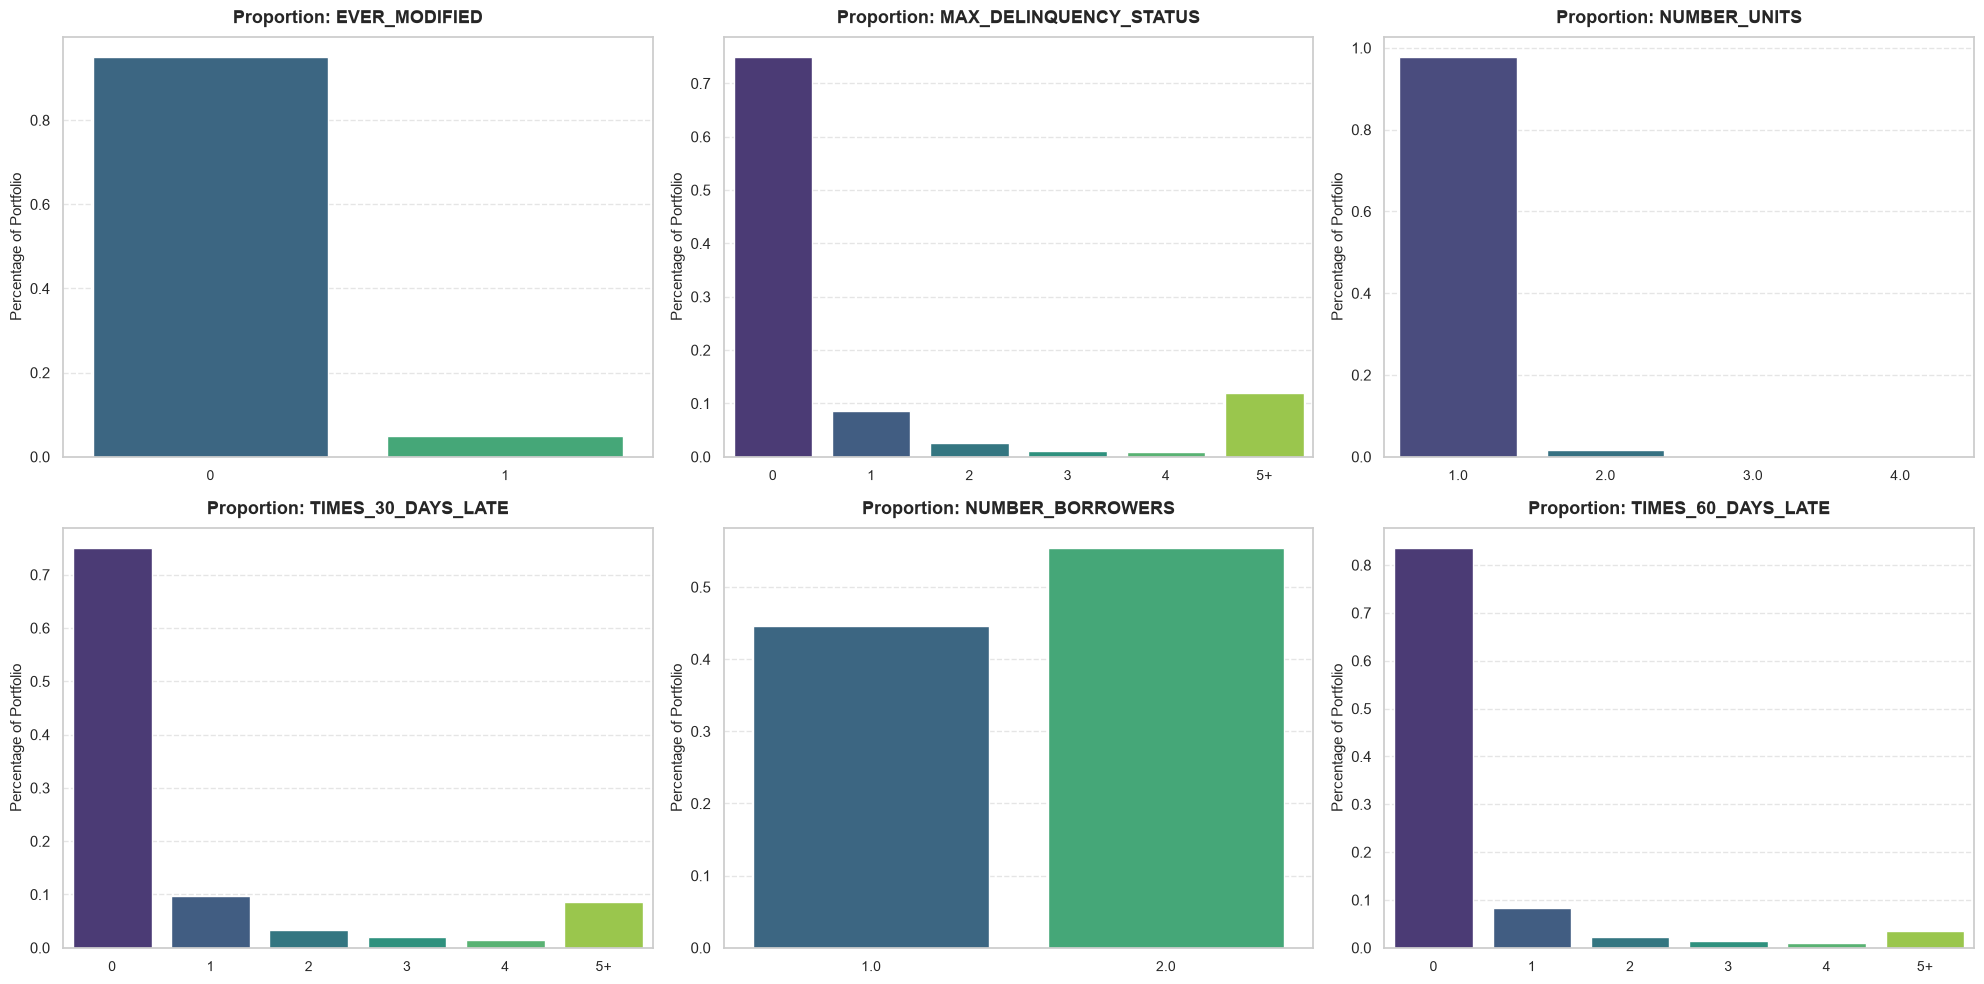

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a temporary copy so we don't accidentally mutate your core dataframe
plot_df = df.copy()

# List of delinquency columns that have messy long tails
delinquency_cols = ['MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE']

# Visually top-cap categories at 5+ for clean, readable layout presentation
for col in delinquency_cols:
    if col in plot_df.columns:
        plot_df[f'{col}_Clean'] = np.where(plot_df[col] >= 5, '5+', plot_df[col].astype(str))
        # Ensure proper sort order: 0, 1, 2, 3, 4, 5+
        sort_order = ['0', '1', '2', '3', '4', '5+', '0.0', '1.0', '2.0', '3.0', '4.0']
        existing_order = [o for o in sort_order if o in plot_df[f'{col}_Clean'].unique()]
        plot_df[f'{col}_Clean'] = pd.Categorical(plot_df[f'{col}_Clean'], categories=existing_order, ordered=True)

# Define full plotting list matching your grid layout
discrete_plot_features = [
    ('EVER_MODIFIED', 'EVER_MODIFIED'),
    ('MAX_DELINQUENCY_STATUS_Clean', 'MAX_DELINQUENCY_STATUS'),
    ('NUMBER_UNITS', 'NUMBER_UNITS'),
    ('TIMES_30_DAYS_LATE_Clean', 'TIMES_30_DAYS_LATE'),
    ('NUMBER_BORROWERS', 'NUMBER_BORROWERS'),
    ('TIMES_60_DAYS_LATE_Clean', 'TIMES_60_DAYS_LATE')
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, (col_name, original_label) in enumerate(discrete_plot_features):
    # Calculate exact percentages for the Y-axis
    prop_data = plot_df[col_name].value_counts(normalize=True).sort_index().reset_index()
    prop_data.columns = [col_name, 'percentage']
    
    # Plot using a clean, uniform palette
    sns.barplot(data=prop_data, x=col_name, y='percentage', ax=axes[i], palette='viridis')
    
    # Titles and formatting
    axes[i].set_title(f'Proportion: {original_label}', fontsize=13, fontweight='bold', pad=10)
    axes[i].set_ylabel('Percentage of Portfolio', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0, labelsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# # Save lines
plt.savefig('discrete_features_proportions_clean.png', dpi=300, bbox_inches='tight')
print(" Figure Saved Successfully as 'discrete_features_proportions_clean.png'")
plt.show()

In [156]:
df.MAX_DELINQUENCY_STATUS.value_counts()

MAX_DELINQUENCY_STATUS
0      112365
1       12829
2        3851
3        1566
5        1510
        ...  
107         1
113         1
118         1
149         1
114         1
Name: count, Length: 120, dtype: int64

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Use your existing continuous features list dynamically
num_cols = len(continuous_features)
grid_cols = 3
grid_rows = math.ceil(num_cols / grid_cols)

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(18, 4 * grid_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    # Dynamically plot using the pre-existing list elements
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue', bins=40, edgecolor='black', alpha=0.7)
    
    axes[i].set_title(f'Histogram of {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Clear out any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('continuous_features_histograms.png', dpi=300, bbox_inches='tight')
plt.close()
plt.show()


Key Econometric InterpretationsThe $80\%$ Institutional Threshold Layering (LTV & CLTV): Notice the massive, vertical spike hitting precisely at 80% in both plots. Econometrically, this represents the standard institutional boundary where lenders historically mandate Private Mortgage Insurance (PMI) to mitigate default risk, causing a massive clustering of loans right up to that policy limit.Extreme Multi-Modality over Time (ORIGINAL_LOAN_TERM): This histogram perfectly illustrates that the variable is not smoothly continuous. The data isolates two distinct operational regimes: a minor spike at 180 months (15-year mortgages) and an absolute monopoly tower at 360 months (30-year mortgages).Zero-Inflated Sparing Dynamics (MI_PERCENT, RATE_INCREASE_MAGNITUDE, FINAL_UPB_RATIO): These plots exhibit extreme, single-column towers at 0.0. This isolates a structurally clean portfolio baseline where the vast majority of active files never undergo crisis restructuring or default liquidations.

## Categorical Vars EDA

### Categorical Feature EDA Summary

---

### Data Engineering & Asset Profile Diagnostics
* **Sentinel Values Cleaned Pre-Split:** Institutional "Unknown" shorthand codes (`9` for `FIRST_TIME_BUYER` and `99` for `PROPERTY_TYPE`) were globally converted to `NaN`. This aligns them with the numerical missing-value workflow, ensuring a clean, unified post-split imputation strategy.
* **Sparsity & Variance Traps Identified:** Prepayment Penalties (`PPM`) exhibit near-zero structural variance, with the portfolio almost entirely uniform (`N`). Similarly, `OCCUPANCY_STATUS` is heavily dominated by Primary Residences (`P`), rendering Investment (`I`) and Second Homes (`S`) sparse sub-segments. 
* **Product Purpose Distribution:** `LOAN_PURPOSE` displays a healthy operational spread across Purchase (`P`), Cash-Out Refinance (`C`), and No Cash-Out Refinance (`N`), providing a robust structural vector for credit performance modeling.
* **Collateral Risk Stratification:** Single-Family homes (`SF`) completely dominate the property mix, while Planned Unit Developments (`PU`) and Condominiums (`CO`) represent small secondary tiers.

---

### Post-Split Encoding & Feature Strategy
* **High-Cardinality Target Mapping:** Geographic and institutional markers with massive dimensionality (`POSTAL_CODE` with 889 unique keys; `MSA` with 450 unique keys) will utilize **Target Encoding** post-split to prevent matrix explosion. Structural missingness in `MSA` (18.67%) will be handled by mapping `NaN` values to a standalone `"Non-MSA/Rural"` category.
* **Standard Structural Dummies:** Bounded categorical attributes (`CHANNEL`, `FIRST_TIME_BUYER`, `PROPERTY_TYPE`, `SELLER_NAME`, `SERVICER_NAME`) will be processed via **One-Hot Encoding** post-split. Encoders will use `handle_unknown='ignore'` to gracefully shield validation steps from crashing on sparse, unseen test-set features.
* **Near-Zero Variance Pruning:** Because `PPM` has near-zero predictive variance (retaining only a microscopic count of `'Y'` values), it will be explicitly dropped from both training and testing matrices post-split to protect model degrees of freedom.
* **Administrative Stripping:** `LOAN_SEQUENCE_NUMBER` has been dropped from the core dataframe pre-split as it serves as a unique primary key record containing zero predictive variance.

In [158]:
print(len(categorical_features))
print(categorical_features)

12
['FIRST_TIME_BUYER', 'OCCUPANCY_STATUS', 'CHANNEL', 'PPM', 'PROPERTY_STATE', 'PROPERTY_TYPE', 'POSTAL_CODE', 'LOAN_SEQUENCE_NUMBER', 'LOAN_PURPOSE', 'SELLER_NAME', 'SERVICER_NAME', 'MSA']


In [159]:
# Real structural categorical features
real_categorical_features = [
    'FIRST_TIME_BUYER', 'OCCUPANCY_STATUS', 'CHANNEL', 'PPM', 
    'PROPERTY_TYPE', 'LOAN_PURPOSE'
]

# High-cardinality/Geographic identifiers
high_cardinality_features = [
    'PROPERTY_STATE', 'POSTAL_CODE', 'LOAN_SEQUENCE_NUMBER', 
    'SELLER_NAME', 'SERVICER_NAME', 'MSA'
]

In [160]:
for col in high_cardinality_features:
    print(f"{col}: {df[col].nunique()} unique values | Missing %: {(df[col].isnull().sum()/len(df))*100:.3f}%")

PROPERTY_STATE: 54 unique values | Missing %: 0.000%
POSTAL_CODE: 889 unique values | Missing %: 0.000%
LOAN_SEQUENCE_NUMBER: 149929 unique values | Missing %: 0.000%
SELLER_NAME: 23 unique values | Missing %: 0.000%
SERVICER_NAME: 24 unique values | Missing %: 0.000%
MSA: 450 unique values | Missing %: 18.669%


C:\Users\Hi\AppData\Local\Temp\ipykernel_4552\2004665461.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prop_data, x=col, y='percentage', ax=axes[i], palette='Set2')
C:\Users\Hi\AppData\Local\Temp\ipykernel_4552\2004665461.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prop_data, x=col, y='percentage', ax=axes[i], palette='Set2')
C:\Users\Hi\AppData\Local\Temp\ipykernel_4552\2004665461.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prop_data, x=col, y='percentage', ax=axes[i], palette='Set2')
C:\Users\Hi\AppD

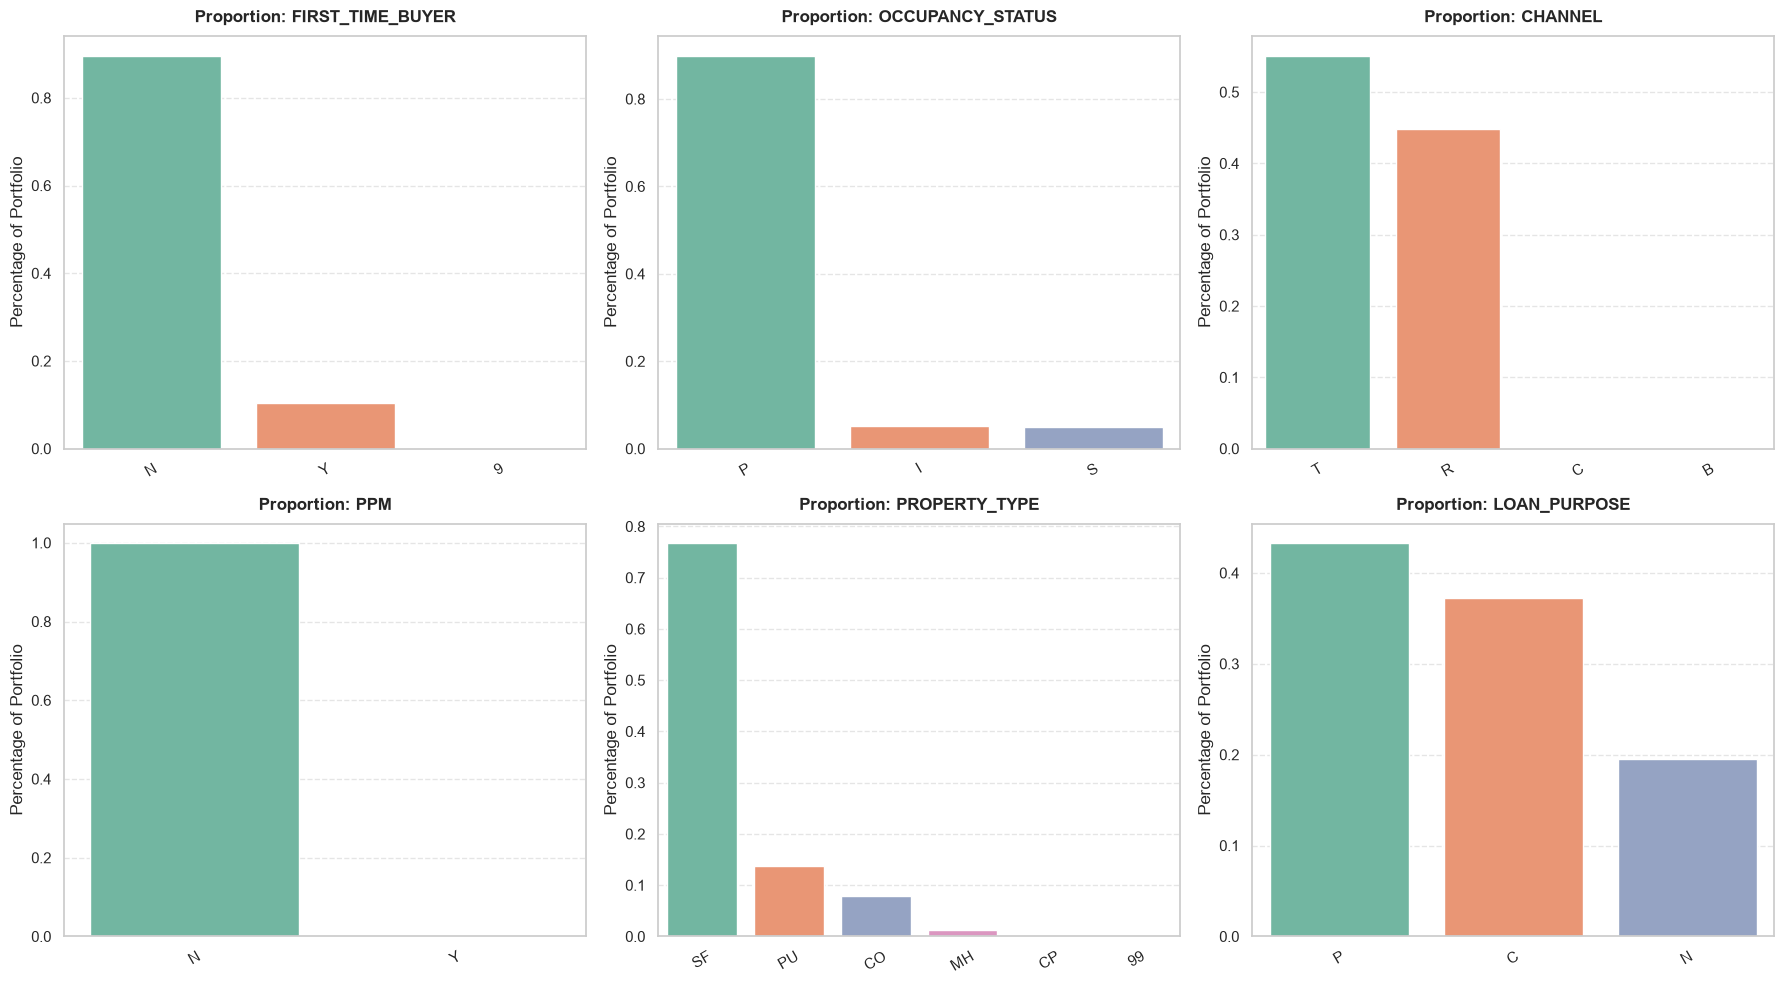

In [162]:
import matplotlib.pyplot as plt  # Fixed typo: changed .subplots to .pyplot
import seaborn as sns
import math

# Define the number of plots and grid layout dimensions
num_cols = len(real_categorical_features)
grid_cols = 3
grid_rows = math.ceil(num_cols / grid_cols)

# Set up the plotting grid canvas
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(18, 5 * grid_rows))
axes = axes.flatten()

# Iterate through every categorical feature and render its proportional distribution
for i, col in enumerate(real_categorical_features):
    # Calculate percentages for the Y-axis to see distribution scale
    prop_data = df[col].value_counts(normalize=True).reset_index()
    prop_data.columns = [col, 'percentage']
    
    # Render the structured bar plot
    sns.barplot(data=prop_data, x=col, y='percentage', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Proportion: {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Percentage of Portfolio')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Drop any empty trailing subplots if the feature count doesn't perfectly fill the grid matrix
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save a clean, high-resolution copy of your categorical EDA grid profile locally
plt.savefig('categorical_features_proportions.png', dpi=300, bbox_inches='tight')
plt.show()

In [163]:
import numpy as np

# Convert categorical sentinel string codes to true NaNs
df['FIRST_TIME_BUYER'] = df['FIRST_TIME_BUYER'].replace('9', np.nan)
df['PROPERTY_TYPE'] = df['PROPERTY_TYPE'].replace('99', np.nan)

# Verification check
print(f"Remaining '9' tokens in FIRST_TIME_BUYER: {(df['FIRST_TIME_BUYER'] == '9').sum()}")
print(f"Remaining '99' tokens in PROPERTY_TYPE: {(df['PROPERTY_TYPE'] == '99').sum()}")
print(f"New total NaN count for FIRST_TIME_BUYER: {df['FIRST_TIME_BUYER'].isna().sum()}")

Remaining '9' tokens in FIRST_TIME_BUYER: 0
Remaining '99' tokens in PROPERTY_TYPE: 0
New total NaN count for FIRST_TIME_BUYER: 28


In [164]:
# Drop the unique identifier column safely
df = df.drop(columns=['LOAN_SEQUENCE_NUMBER'])

In [165]:
df.shape

(149929, 34)

In [166]:
# Save the scrubbed baseline dataset to Parquet format
df.to_parquet('loan_data_post_eda.parquet', index=False)
print(" Milestone Saved: 'loan_data_post_eda.parquet' successfully written.")

 Milestone Saved: 'loan_data_post_eda.parquet' successfully written.


# Macro-Variables Blending

In [167]:
import pandas as pd

# 1. Load the raw macro CSV files (ensure filenames match your directory casing)
brm_df = pd.read_csv('BRMHELOC01.csv')
hpi_df = pd.read_csv('CSUSHPISA.csv')
delinq_df = pd.read_csv('DRSFRMACBS.csv')
mtg_df = pd.read_csv('MORTGAGE30US.csv')

# 2. Inspect column layouts and data frames quickly
print("--- BRMHELOC01 Shape:", brm_df.shape)
print(brm_df.head(2), "\n")

print("--- CSUSHPISA Shape:", hpi_df.shape)
print(hpi_df.head(2), "\n")

print("--- DRSFRMACBS Shape:", delinq_df.shape)
print(delinq_df.head(2), "\n")

print("--- MORTGAGE30US Shape:", mtg_df.shape)
print(mtg_df.head(2))

--- BRMHELOC01 Shape: (626, 2)
  observation_date  BRMHELOC01
0       2004-01-07        4.76
1       2004-01-14        4.74 

--- CSUSHPISA Shape: (144, 2)
  observation_date  CSUSHPISA
0       2004-01-01    141.647
1       2004-02-01    143.191 

--- DRSFRMACBS Shape: (48, 2)
  observation_date  DRSFRMACBS
0       2004-01-01        1.64
1       2004-04-01        1.60 

--- MORTGAGE30US Shape: (626, 2)
  observation_date  MORTGAGE30US
0       2004-01-08          5.87
1       2004-01-15          5.66


In [169]:
brm_df.head()

,observation_date,BRMHELOC01
0,2004-01-07,4.76
1,2004-01-14,4.74
2,2004-01-21,4.74
3,2004-01-28,4.74
4,2004-02-04,4.71


In [170]:
mtg_df.head()

,observation_date,MORTGAGE30US
0,2004-01-08,5.87
1,2004-01-15,5.66
2,2004-01-22,5.64
3,2004-01-29,5.68
4,2004-02-05,5.72


In [171]:
delinq_df.head()

,observation_date,DRSFRMACBS
0,2004-01-01,1.64
1,2004-04-01,1.60
2,2004-07-01,1.56
3,2004-10-01,1.41
4,2005-01-01,1.42


In [ ]:
    import pandas as pd
    import numpy as np

    macro_files = {
        'Bank Prime Rate (BRMHELOC01)': brm_df,
        'Case-Shiller HPI (CSUSHPISA)': hpi_df,
        'Bank Delinquency Rate (DRSFRMACBS)': delinq_df,
        '30Yr Mortgage Rate (MORTGAGE30US)': mtg_df
    }

    # Run automated cleanliness check
    for name, df in macro_files.items():
        print(f"=== Diagnostics for: {name} ===")
        print(f"Columns & Types:\n{df.dtypes}\n")
        
        # Check for FRED's classic holiday dot character '.'
        for col in df.columns:
            dot_count = (df[col] == '.').sum() if df[col].dtype == 'object' else 0
            if dot_count > 0:
                print(f" WARNING: Found {dot_count} text dot placeholders ('.') in column '{col}'!")
                
        print(f"Missing Values (NaN): {df.isna().sum().sum()}")
        print(f"First Row Date: {df.iloc[0, 0]} | Last Row Date: {df.iloc[-1, 0]}")
        print("-" * 50)

=== Diagnostics for: Bank Prime Rate (BRMHELOC01) ===
Columns & Types:
observation_date        str
BRMHELOC01          float64
dtype: object

Missing Values (NaN): 0
First Row Date: 2004-01-07 | Last Row Date: 2015-12-30
--------------------------------------------------
=== Diagnostics for: Case-Shiller HPI (CSUSHPISA) ===
Columns & Types:
observation_date        str
CSUSHPISA           float64
dtype: object

Missing Values (NaN): 0
First Row Date: 2004-01-01 | Last Row Date: 2015-12-01
--------------------------------------------------
=== Diagnostics for: Bank Delinquency Rate (DRSFRMACBS) ===
Columns & Types:
observation_date        str
DRSFRMACBS          float64
dtype: object

Missing Values (NaN): 0
First Row Date: 2004-01-01 | Last Row Date: 2015-10-01
--------------------------------------------------
=== Diagnostics for: 30Yr Mortgage Rate (MORTGAGE30US) ===
Columns & Types:
observation_date        str
MORTGAGE30US        float64
dtype: object

Missing Values (NaN): 0
First R

In [ ]:
import pandas as pd

# 1. Standardize dates and set as index
for temp_df in [brm_df, hpi_df, delinq_df, mtg_df]:
    temp_df['observation_date'] = pd.to_datetime(temp_df['observation_date'])
    temp_df.set_index('observation_date', inplace=True)

# 2. Resample to standard Month-Start frequencies
brm_monthly = brm_df.resample('MS').mean()
mtg_monthly = mtg_df.resample('MS').mean()
    hpi_monthly = hpi_df.resample('MS').first()
delinq_monthly = delinq_df.resample('MS').ffill()



In [173]:
brm_monthly.head()

,BRMHELOC01
observation_date,
2004-01-01,4.7450
2004-02-01,4.7250
2004-03-01,4.6740
2004-04-01,4.6950
2004-05-01,4.7125


In [175]:
brm_df.head(10)

,BRMHELOC01
observation_date,
2004-01-07,4.76
2004-01-14,4.74
2004-01-21,4.74
2004-01-28,4.74
2004-02-04,4.71
2004-02-11,4.72
2004-02-18,4.72
2004-02-25,4.75
2004-03-03,4.69


In [176]:
delinq_monthly.head()

,DRSFRMACBS
observation_date,
2004-01-01,1.64
2004-02-01,1.64
2004-03-01,1.64
2004-04-01,1.60
2004-05-01,1.60


In [177]:
delinq_df.head()

,DRSFRMACBS
observation_date,
2004-01-01,1.64
2004-04-01,1.60
2004-07-01,1.56
2004-10-01,1.41
2005-01-01,1.42


In [178]:
hpi_monthly.head()

,CSUSHPISA
observation_date,
2004-01-01,141.647
2004-02-01,143.191
2004-03-01,145.059
2004-04-01,146.593
2004-05-01,148.186


In [179]:
hpi_df.head()

,CSUSHPISA
observation_date,
2004-01-01,141.647
2004-02-01,143.191
2004-03-01,145.059
2004-04-01,146.593
2004-05-01,148.186


In [180]:
# 3. Combine into the Master Macro Dataframe
macro_master = pd.concat([hpi_monthly, brm_monthly, mtg_monthly, delinq_monthly], axis=1)

# 4. Generate an INTEGER key matching your 'YYYYMM' structure
macro_master['JOIN_YEAR_MONTH'] = macro_master.index.strftime('%Y%m').astype(int)
macro_master.reset_index(drop=True, inplace=True)

# 5. Quick look to confirm the data types match perfectly
print("=== Macro Master Dataframe ===")
print(macro_master.dtypes)
print(macro_master.head(2))

=== Macro Master Dataframe ===
CSUSHPISA          float64
BRMHELOC01         float64
MORTGAGE30US       float64
DRSFRMACBS         float64
JOIN_YEAR_MONTH      int64
dtype: object
   CSUSHPISA  BRMHELOC01  MORTGAGE30US  DRSFRMACBS  JOIN_YEAR_MONTH
0    141.647       4.745        5.7125        1.64           200401
1    143.191       4.725        5.6350        1.64           200402


In [185]:
import pandas as pd

# 1. Reload your clean baseline loan data as 'df'
df = pd.read_parquet('loan_data_post_eda.parquet')

In [186]:
df.head()

,CREDIT_SCORE,FIRST_PAYMENT_DATE,FIRST_TIME_BUYER,MATURITY_DATE,MSA,MI_PERCENT,NUMBER_UNITS,OCCUPANCY_STATUS,CLTV,DTI,ORIGINAL_UPB,LTV,ORIGINAL_INTEREST_RATE,CHANNEL,PPM,PROPERTY_STATE,PROPERTY_TYPE,POSTAL_CODE,LOAN_PURPOSE,ORIGINAL_LOAN_TERM,NUMBER_BORROWERS,SELLER_NAME,SERVICER_NAME,ORIGINATION_YEAR,LOAN_LIFESPAN_MONTHS,TOTAL_ACTUAL_LOSS,MAX_DELINQUENCY_STATUS,TIMES_30_DAYS_LATE,TIMES_60_DAYS_LATE,RATE_INCREASE_MAGNITUDE,FINAL_UPB_RATIO,EVER_MODIFIED,DEFAULT_INDICATOR,JOIN_YEAR_MONTH
0,742.0,2008-02-01,N,2038-01-01,41500.0,0,1.0,P,39.0,42.0,265000,39.0,5.750,T,N,CA,SF,93900,C,360,1.0,Other sellers,Other servicers,2008,33,0.0,0,0,0,0.0,0.0,0,0,200802
1,734.0,2008-02-01,N,2038-01-01,33460.0,12,1.0,I,85.0,35.0,197000,85.0,6.625,R,N,MN,PU,55300,N,360,1.0,Other sellers,Other servicers,2008,107,0.0,0,0,0,0.0,0.0,0,0,200802
2,667.0,2008-02-01,N,2038-01-01,45300.0,25,1.0,P,90.0,28.0,257000,90.0,6.500,R,N,FL,SF,33600,C,360,1.0,WASHINGTON MUTUAL BANK,"SELECT PORTFOLIO SERVICING, INC.",2008,81,0.0,43,19,19,2.5,0.0,1,1,200802
3,725.0,2008-02-01,N,2038-01-01,47260.0,25,1.0,I,86.0,48.0,122000,86.0,6.875,T,N,VA,SF,23300,N,360,1.0,"GMAC MORTGAGE, LLC","GMAC MORTGAGE, LLC",2008,58,0.0,0,0,0,0.0,0.0,0,0,200802
4,777.0,2008-02-01,N,2038-01-01,33340.0,0,1.0,P,55.0,46.0,417000,55.0,5.750,T,N,WI,SF,53000,N,360,2.0,"TAYLOR, BEAN & WHITAKER MORTGAGE CORP.","TAYLOR, BEAN & WHITAKER MORTGAGE CORP.",2008,13,0.0,0,0,0,0.0,0.0,0,0,200802


In [188]:
df.shape

(149929, 34)

In [189]:
# 2. Perform the explicit left-join into your master macro dataframe
df_macro = df.merge(macro_master, on='JOIN_YEAR_MONTH', how='left')

In [190]:
# 3. Verify the final enriched structure
print("=== Integration Complete ===")
print(f"Master Macro Reservoir Shape: {df_macro.shape}")
print(df_macro[['JOIN_YEAR_MONTH', 'CSUSHPISA', 'BRMHELOC01', 'MORTGAGE30US']].head(3))

=== Integration Complete ===
Master Macro Reservoir Shape: (149929, 38)
   JOIN_YEAR_MONTH  CSUSHPISA  BRMHELOC01  MORTGAGE30US
0           200802    171.539        6.38        5.9175
1           200802    171.539        6.38        5.9175
2           200802    171.539        6.38        5.9175


In [191]:
df_macro.head()

,CREDIT_SCORE,FIRST_PAYMENT_DATE,FIRST_TIME_BUYER,MATURITY_DATE,MSA,MI_PERCENT,NUMBER_UNITS,OCCUPANCY_STATUS,CLTV,DTI,ORIGINAL_UPB,LTV,ORIGINAL_INTEREST_RATE,CHANNEL,PPM,PROPERTY_STATE,PROPERTY_TYPE,POSTAL_CODE,LOAN_PURPOSE,ORIGINAL_LOAN_TERM,NUMBER_BORROWERS,SELLER_NAME,SERVICER_NAME,ORIGINATION_YEAR,LOAN_LIFESPAN_MONTHS,TOTAL_ACTUAL_LOSS,MAX_DELINQUENCY_STATUS,TIMES_30_DAYS_LATE,TIMES_60_DAYS_LATE,RATE_INCREASE_MAGNITUDE,FINAL_UPB_RATIO,EVER_MODIFIED,DEFAULT_INDICATOR,JOIN_YEAR_MONTH,CSUSHPISA,BRMHELOC01,MORTGAGE30US,DRSFRMACBS
0,742.0,2008-02-01,N,2038-01-01,41500.0,0,1.0,P,39.0,42.0,265000,39.0,5.750,T,N,CA,SF,93900,C,360,1.0,Other sellers,Other servicers,2008,33,0.0,0,0,0,0.0,0.0,0,0,200802,171.539,6.38,5.9175,3.67
1,734.0,2008-02-01,N,2038-01-01,33460.0,12,1.0,I,85.0,35.0,197000,85.0,6.625,R,N,MN,PU,55300,N,360,1.0,Other sellers,Other servicers,2008,107,0.0,0,0,0,0.0,0.0,0,0,200802,171.539,6.38,5.9175,3.67
2,667.0,2008-02-01,N,2038-01-01,45300.0,25,1.0,P,90.0,28.0,257000,90.0,6.500,R,N,FL,SF,33600,C,360,1.0,WASHINGTON MUTUAL BANK,"SELECT PORTFOLIO SERVICING, INC.",2008,81,0.0,43,19,19,2.5,0.0,1,1,200802,171.539,6.38,5.9175,3.67
3,725.0,2008-02-01,N,2038-01-01,47260.0,25,1.0,I,86.0,48.0,122000,86.0,6.875,T,N,VA,SF,23300,N,360,1.0,"GMAC MORTGAGE, LLC","GMAC MORTGAGE, LLC",2008,58,0.0,0,0,0,0.0,0.0,0,0,200802,171.539,6.38,5.9175,3.67
4,777.0,2008-02-01,N,2038-01-01,33340.0,0,1.0,P,55.0,46.0,417000,55.0,5.750,T,N,WI,SF,53000,N,360,2.0,"TAYLOR, BEAN & WHITAKER MORTGAGE CORP.","TAYLOR, BEAN & WHITAKER MORTGAGE CORP.",2008,13,0.0,0,0,0,0.0,0.0,0,0,200802,171.539,6.38,5.9175,3.67


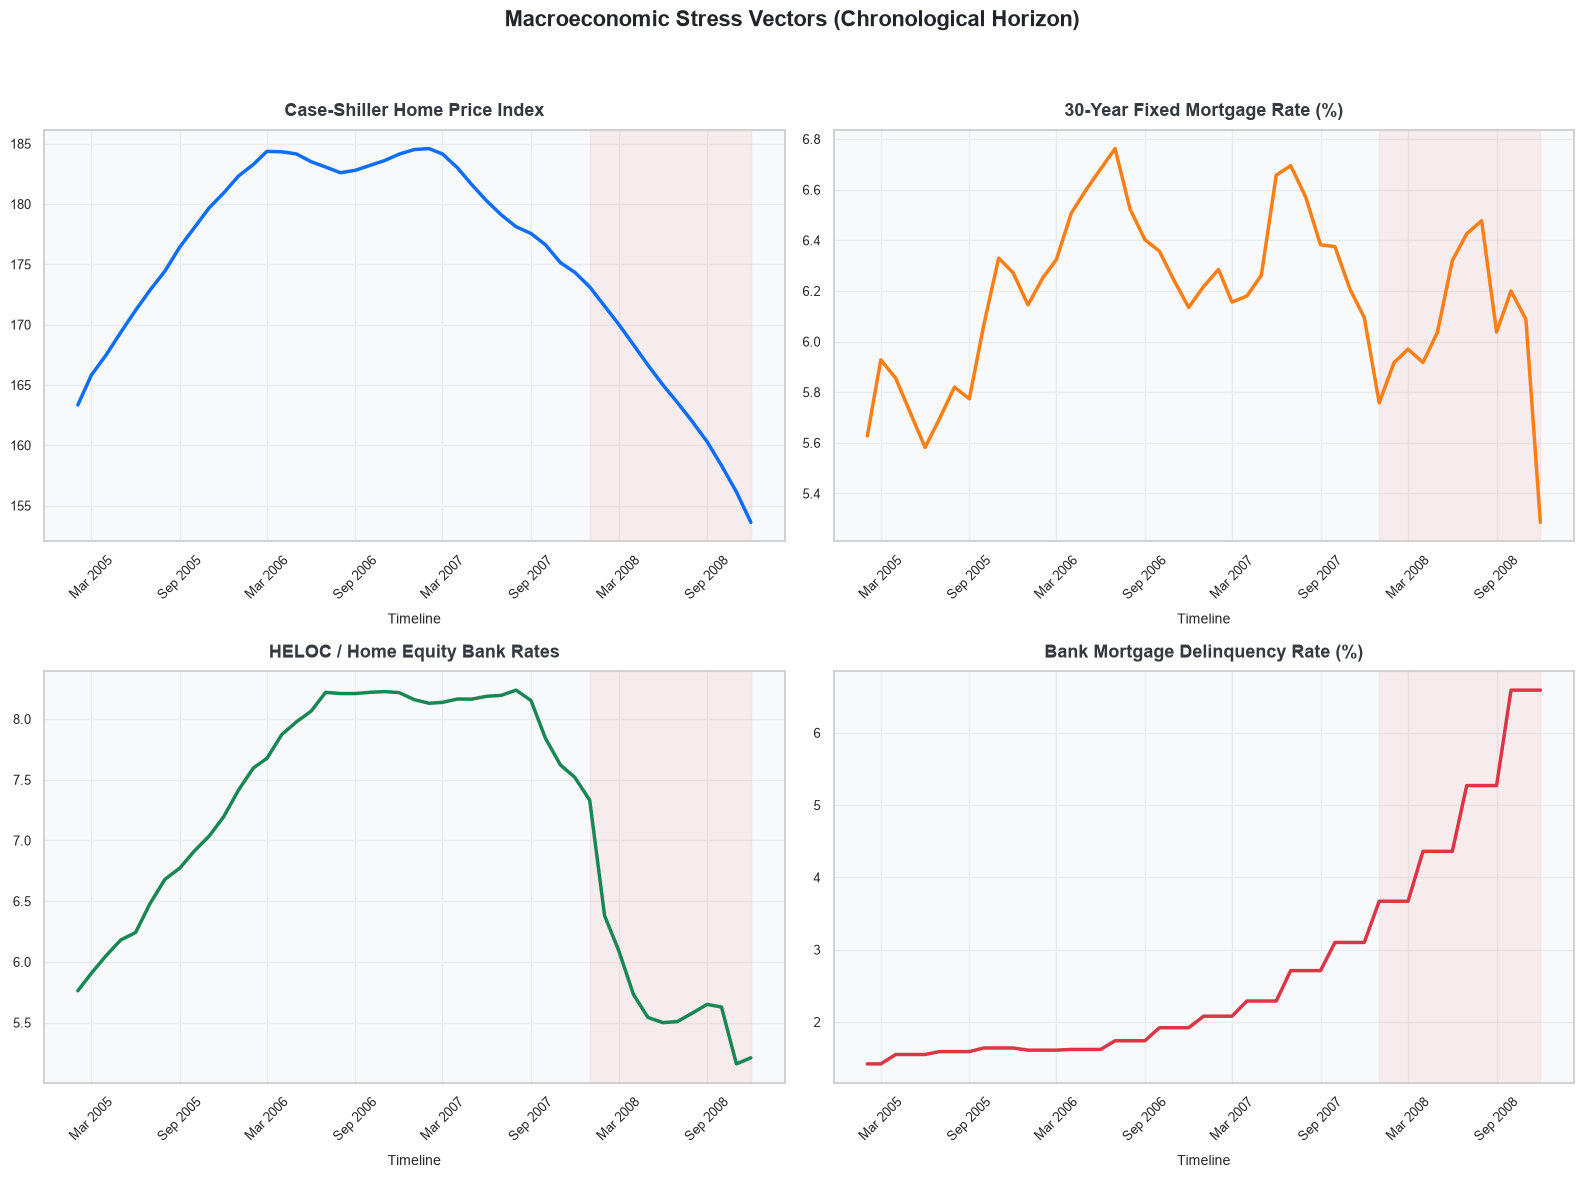

In [261]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Use your existing datetime object to sort and drop duplicate periods smoothly
df_plot = df_macro.sort_values(by='FIRST_PAYMENT_DATE').drop_duplicates(subset=['JOIN_YEAR_MONTH'])

# 2. Set up an institutional banking theme
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#f8f9fa", "grid.color": "#e9ecef"})
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Macroeconomic Stress Vectors (Chronological Horizon)', fontsize=16, fontweight='bold', color='#212529')

macro_plots = [
    ('CSUSHPISA', 'Case-Shiller Home Price Index', '#0d6efd', (0,0)),
    ('MORTGAGE30US', '30-Year Fixed Mortgage Rate (%)', '#fd7e14', (0,1)),
    ('BRMHELOC01', 'HELOC / Home Equity Bank Rates', '#198754', (1,0)),
    ('DRSFRMACBS', 'Bank Mortgage Delinquency Rate (%)', '#dc3545', (1,1))
]

for col, title, color, pos in macro_plots:
    ax = axes[pos[0], pos[1]]
    if col in df_plot.columns:
        # Plot using the original datetime object for perfect chronological spacing
        sns.lineplot(data=df_plot, x='FIRST_PAYMENT_DATE', y=col, ax=ax, color=color, linewidth=2.5)
        
        # Typography & Layout Cleanup
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10, color='#343a40')
        ax.set_xlabel('Timeline', fontsize=10, labelpad=8)
        ax.set_ylabel('') 
        
        # --- THE AXIS FIX ENGINE ---
        # Format ticks cleanly as 'Jan 2006' every 6 months using the datetime axis
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', labelrotation=45, labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
        
        # Visual Highlight: Shade our 2008 Out-of-Time Stress Test Window
        ax.axvspan('2008-01-01', df_plot['FIRST_PAYMENT_DATE'].max(), color='#dc3545', alpha=0.07, label='OOT Firewall')
    else:
        ax.text(0.5, 0.5, f'{col} Missing', ha='center', va='center', fontsize=12)

plt.savefig("Macro_Variables_Visualised")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Macro Stress Vectors: Institutional Interpretation

* **CSUSHPISA (Home Prices):** Peak bubble in 2006 followed by a severe, unchecked crash entering the 2008 OOT Firewall. This drove **LTV Drift**, stripping away borrower equity and eliminating refinancing options, which triggered rational default.
* **MORTGAGE30US (30-Yr Fixed Rates):** Climbed relentlessly toward 6.8% in 2006–2007. This rate-hiking cycle induced severe **payment shock** for adjustable-rate mortgage (ARM) borrowers as their teaser periods expired.
* **BRMHELOC01 (HELOC Rates):** Remained punishingly high (>8%) pre-crisis, then experienced a near-vertical drop in 2008. This drop reflects emergency rate cuts, but more critically, a **systemic credit freeze** where banks revoked home equity lines, eliminating consumer liquidity cushions.
* **DRSFRMACBS (Delinquency Rate):** Bounded tightly at a safe 1.5%–2.0% baseline during the 2005–2007 training window, then experienced an **exponential breakout past 6.5%** in 2008. This validates that the OOT test pool is a true, systemic economic crisis firewall.

In [192]:
# Save the master macro data reservoir to Parquet format
df_macro.to_parquet('loan_data_macro_reservoir.parquet', index=False)
print(" Milestone Saved: 'loan_data_macro_reservoir.parquet' successfully written.")

 Milestone Saved: 'loan_data_macro_reservoir.parquet' successfully written.


# OOT Split

In [193]:
print(df_macro['ORIGINATION_YEAR'].value_counts().sort_index())

ORIGINATION_YEAR
2005    41986
2006    49393
2007    49995
2008     8555
Name: count, dtype: int64


In [194]:
df.DEFAULT_INDICATOR.value_counts()

DEFAULT_INDICATOR
0    128955
1     20974
Name: count, dtype: int64

In [195]:
df.EVER_MODIFIED.value_counts()

EVER_MODIFIED
0    142444
1      7485
Name: count, dtype: int64

In [200]:
df_macro.shape

(149929, 38)

In [198]:
df_macro.columns

Index(['CREDIT_SCORE', 'FIRST_PAYMENT_DATE', 'FIRST_TIME_BUYER',
       'MATURITY_DATE', 'MSA', 'MI_PERCENT', 'NUMBER_UNITS',
       'OCCUPANCY_STATUS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV',
       'ORIGINAL_INTEREST_RATE', 'CHANNEL', 'PPM', 'PROPERTY_STATE',
       'PROPERTY_TYPE', 'POSTAL_CODE', 'LOAN_PURPOSE', 'ORIGINAL_LOAN_TERM',
       'NUMBER_BORROWERS', 'SELLER_NAME', 'SERVICER_NAME', 'ORIGINATION_YEAR',
       'LOAN_LIFESPAN_MONTHS', 'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS',
       'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE',
       'FINAL_UPB_RATIO', 'EVER_MODIFIED', 'DEFAULT_INDICATOR',
       'JOIN_YEAR_MONTH', 'CSUSHPISA', 'BRMHELOC01', 'MORTGAGE30US',
       'DRSFRMACBS'],
      dtype='str')

In [214]:
    import pandas as pd
    from sklearn.model_selection import train_test_split

    # 1. Set the target variable
    target_col = 'DEFAULT_INDICATOR'

    # 2. Columns to drop to preserve a pure Underwriting Framework
    meta_cols = ['ORIGINATION_YEAR', 'JOIN_YEAR_MONTH', 'FIRST_PAYMENT_DATE', 'MATURITY_DATE']
    leakage_cols = [
        'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'MAX_DELINQUENCY_STATUS',
        'TOTAL_ACTUAL_LOSS', 'FINAL_UPB_RATIO', 'EVER_MODIFIED', 'LOAN_LIFESPAN_MONTHS'
    ]
    drop_cols = [target_col] + meta_cols + leakage_cols

    # 3. Create the Out-of-Time (OOT) Split (2008 as the firewall)
    test_mask = df_macro['ORIGINATION_YEAR'] == 2008
    df_dev = df_macro[~test_mask].copy()
    df_test = df_macro[test_mask].copy()

    # 4. Extract target vectors
    y_dev = df_dev[target_col]
    y_test = df_test[target_col]

    # 5. Extract feature matrices (pure origination-time metrics + macro metrics)
    X_dev_clean = df_dev.drop(columns=drop_cols, errors='ignore')
    X_test = df_test.drop(columns=drop_cols, errors='ignore')

    # 6. Stratified split of the Development Pool (2005–2007) into Train/Val (80/20)
    X_train, X_val, y_train, y_val = train_test_split(
        X_dev_clean, 
        y_dev, 
        test_size=0.20, 
        random_state=42, 
        stratify=y_dev
    )

    # 7. Verify the final data assets
    print("=== Underwriting OOT Split Complete ===")
    print(f"Train Features Shape:      {X_train.shape} | Default Rate: {y_train.mean():.2%}")
    print(f"Validation Features Shape:  {X_val.shape}  | Default Rate: {y_val.mean():.2%}")
    print(f"OOT Test Features Shape:    {X_test.shape}  | Default Rate: {y_test.mean():.2%}")
    print(f"\nNumber of clean features active: {X_train.shape[1]}")


=== Underwriting OOT Split Complete ===
Train Features Shape:      (113099, 26) | Default Rate: 13.83%
Validation Features Shape:  (28275, 26)  | Default Rate: 13.83%
OOT Test Features Shape:    (8555, 26)  | Default Rate: 16.67%

Number of clean features active: 26


In [216]:
X_train

,CREDIT_SCORE,FIRST_TIME_BUYER,MSA,MI_PERCENT,NUMBER_UNITS,OCCUPANCY_STATUS,CLTV,DTI,ORIGINAL_UPB,LTV,ORIGINAL_INTEREST_RATE,CHANNEL,PPM,PROPERTY_STATE,PROPERTY_TYPE,POSTAL_CODE,LOAN_PURPOSE,ORIGINAL_LOAN_TERM,NUMBER_BORROWERS,SELLER_NAME,SERVICER_NAME,RATE_INCREASE_MAGNITUDE,CSUSHPISA,BRMHELOC01,MORTGAGE30US,DRSFRMACBS
132230,751.0,N,NaN,0,1.0,P,80.0,61.0,164000,80.0,6.375,T,N,WA,SF,98800,P,360,2.0,Other sellers,"WELLS FARGO BANK, N.A.",0.000,184.148,8.1375,6.1560,2.08
131448,639.0,N,12580.0,12,1.0,P,85.0,50.0,146000,85.0,6.000,R,N,MD,SF,21200,C,360,1.0,"COUNTRYWIDE HOME LOANS, INC.","SELECT PORTFOLIO SERVICING, INC.",1.000,184.596,8.1300,6.2850,2.08
140290,782.0,N,NaN,0,2.0,I,80.0,44.0,113000,80.0,7.250,T,N,MO,SF,64100,P,360,1.0,Other sellers,Other servicers,0.000,177.556,8.1525,6.3825,2.71
38736,620.0,N,38060.0,0,1.0,P,53.0,45.0,417000,53.0,6.125,T,N,AZ,PU,85000,C,360,1.0,"WELLS FARGO BANK, N.A.",SPECIALIZED LOAN SERVICING LLC,4.125,184.157,7.9760,6.5975,1.62
41146,746.0,N,29820.0,0,1.0,P,30.0,44.0,150000,30.0,5.875,R,N,NV,PU,89100,C,360,2.0,"WELLS FARGO BANK, N.A.","WELLS FARGO BANK, N.A.",0.000,172.861,6.4800,5.6950,1.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45629,753.0,N,NaN,0,1.0,P,66.0,20.0,110000,66.0,6.000,R,N,MT,SF,59600,P,360,2.0,Other sellers,Other servicers,0.000,184.596,8.1300,6.2850,2.08
36683,663.0,Y,19804.0,0,1.0,P,100.0,43.0,101000,80.0,6.625,T,N,MI,SF,48200,P,360,1.0,"COUNTRYWIDE HOME LOANS, INC.","COUNTRYWIDE HOME LOANS, INC.",0.000,183.508,8.0650,6.6820,1.62
10435,781.0,Y,45300.0,0,1.0,P,80.0,31.0,298000,80.0,6.000,T,N,FL,PU,33500,P,360,2.0,"BANK OF AMERICA, N.A.","OCWEN LOAN SERVICING, LLC",0.000,178.115,8.2380,6.5720,2.71
85467,794.0,Y,20764.0,30,1.0,P,95.0,42.0,263000,95.0,6.000,R,N,NJ,CO,08800,P,360,1.0,Other sellers,Other servicers,0.000,182.322,7.4150,6.1450,1.61


In [217]:
X_val

,CREDIT_SCORE,FIRST_TIME_BUYER,MSA,MI_PERCENT,NUMBER_UNITS,OCCUPANCY_STATUS,CLTV,DTI,ORIGINAL_UPB,LTV,ORIGINAL_INTEREST_RATE,CHANNEL,PPM,PROPERTY_STATE,PROPERTY_TYPE,POSTAL_CODE,LOAN_PURPOSE,ORIGINAL_LOAN_TERM,NUMBER_BORROWERS,SELLER_NAME,SERVICER_NAME,RATE_INCREASE_MAGNITUDE,CSUSHPISA,BRMHELOC01,MORTGAGE30US,DRSFRMACBS
138602,777.0,N,41100.0,0,1.0,I,53.0,25.0,110000,53.0,5.875,T,N,UT,PU,84700,P,360,2.0,Other sellers,"CITIMORTGAGE, INC.",0.0,165.815,5.9060,5.9280,1.42
108597,694.0,N,23104.0,0,1.0,P,79.0,26.0,250000,79.0,7.000,R,N,TX,SF,76200,P,360,1.0,"BANK OF AMERICA, N.A.","BANK OF AMERICA, N.A.",0.0,178.115,8.2380,6.5720,2.71
145299,722.0,N,NaN,0,1.0,P,78.0,30.0,78000,78.0,5.875,T,N,IN,SF,46500,N,360,1.0,"WELLS FARGO BANK, N.A.","WELLS FARGO BANK, N.A.",0.0,179.684,7.0360,6.3300,1.64
140022,809.0,N,41140.0,0,1.0,P,56.0,32.0,72000,56.0,6.750,R,N,MO,SF,64400,P,360,2.0,CHASE HOME FINANCE LLC,"JPMORGAN CHASE BANK, N.A.",0.0,184.137,8.2175,6.1350,1.92
31420,728.0,N,19124.0,0,1.0,P,80.0,34.0,231000,80.0,6.375,T,N,TX,SF,75100,P,360,2.0,"WELLS FARGO BANK, N.A.","WELLS FARGO BANK, N.A.",0.0,183.288,7.5975,6.2525,1.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139536,732.0,N,NaN,0,3.0,I,79.0,24.0,126000,79.0,6.375,R,N,PA,SF,19400,N,360,2.0,"WELLS FARGO BANK, N.A.","WELLS FARGO BANK, N.A.",0.0,180.253,8.1875,6.6575,2.29
115335,692.0,N,47664.0,0,1.0,P,70.0,22.0,115000,70.0,6.250,R,N,MI,SF,48300,P,240,1.0,CHASE HOME FINANCE LLC,"JPMORGAN CHASE BANK, N.A.",0.0,181.600,8.1640,6.2620,2.29
87604,659.0,N,47260.0,0,1.0,P,53.0,42.0,68000,53.0,5.875,T,N,VA,SF,23400,C,180,2.0,"ABN AMRO MORTGAGE GROUP, INC.",NATIONSTAR MORTGAGE LLC DBA MR. COOPER,0.0,172.861,6.4800,5.6950,1.59
105500,778.0,N,44060.0,0,1.0,P,80.0,31.0,109000,80.0,6.125,T,N,WA,PU,99000,P,360,1.0,"WELLS FARGO BANK, N.A.","WELLS FARGO BANK, N.A.",0.0,184.365,7.6760,6.3240,1.61


In [218]:
X_test

,CREDIT_SCORE,FIRST_TIME_BUYER,MSA,MI_PERCENT,NUMBER_UNITS,OCCUPANCY_STATUS,CLTV,DTI,ORIGINAL_UPB,LTV,ORIGINAL_INTEREST_RATE,CHANNEL,PPM,PROPERTY_STATE,PROPERTY_TYPE,POSTAL_CODE,LOAN_PURPOSE,ORIGINAL_LOAN_TERM,NUMBER_BORROWERS,SELLER_NAME,SERVICER_NAME,RATE_INCREASE_MAGNITUDE,CSUSHPISA,BRMHELOC01,MORTGAGE30US,DRSFRMACBS
0,742.0,N,41500.0,0,1.0,P,39.0,42.0,265000,39.0,5.750,T,N,CA,SF,93900,C,360,1.0,Other sellers,Other servicers,0.0,171.539,6.380,5.9175,3.67
1,734.0,N,33460.0,12,1.0,I,85.0,35.0,197000,85.0,6.625,R,N,MN,PU,55300,N,360,1.0,Other sellers,Other servicers,0.0,171.539,6.380,5.9175,3.67
2,667.0,N,45300.0,25,1.0,P,90.0,28.0,257000,90.0,6.500,R,N,FL,SF,33600,C,360,1.0,WASHINGTON MUTUAL BANK,"SELECT PORTFOLIO SERVICING, INC.",2.5,171.539,6.380,5.9175,3.67
3,725.0,N,47260.0,25,1.0,I,86.0,48.0,122000,86.0,6.875,T,N,VA,SF,23300,N,360,1.0,"GMAC MORTGAGE, LLC","GMAC MORTGAGE, LLC",0.0,171.539,6.380,5.9175,3.67
4,777.0,N,33340.0,0,1.0,P,55.0,46.0,417000,55.0,5.750,T,N,WI,SF,53000,N,360,2.0,"TAYLOR, BEAN & WHITAKER MORTGAGE CORP.","TAYLOR, BEAN & WHITAKER MORTGAGE CORP.",0.0,171.539,6.380,5.9175,3.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149896,767.0,N,12580.0,0,1.0,P,70.0,13.0,171000,70.0,6.125,R,N,MD,SF,21200,C,360,2.0,FIRST HORIZON HOME LOAN CORPORATION,Other servicers,0.0,171.539,6.380,5.9175,3.67
149907,716.0,Y,13820.0,35,1.0,P,100.0,37.0,128000,100.0,6.500,T,N,AL,CO,35200,P,360,1.0,"CITIMORTGAGE, INC.","CITIMORTGAGE, INC.",0.0,171.539,6.380,5.9175,3.67
149915,810.0,N,15764.0,0,1.0,P,58.0,13.0,417000,58.0,6.375,R,N,MA,SF,02400,P,360,2.0,"BANK OF AMERICA, N.A.","BANK OF AMERICA, N.A.",0.0,171.539,6.380,5.9175,3.67
149922,801.0,N,35644.0,0,1.0,P,75.0,NaN,314000,75.0,6.250,T,N,NJ,SF,07400,N,360,1.0,"WELLS FARGO BANK, N.A.","WELLS FARGO BANK, N.A.",0.0,173.131,7.332,5.7580,3.67


In [219]:
import pandas as pd

print(" Saving raw institutional data splits to Parquet format...")

# 1. Save the raw Feature Matrices (X)
X_train.to_parquet('X_train_raw.parquet', index=False)
X_val.to_parquet('X_val_raw.parquet', index=False)
X_test.to_parquet('X_test_raw.parquet', index=False)

# 2. Save Target Series (y) to DataFrames to preserve the structure
pd.DataFrame(y_train).to_parquet('y_train.parquet', index=False)
pd.DataFrame(y_val).to_parquet('y_val.parquet', index=False)
pd.DataFrame(y_test).to_parquet('y_test.parquet', index=False)

print("\n🔒 Raw data reservoirs successfully secured on disk!")
print("  -> 'X_train_raw.parquet' & 'y_train.parquet'")
print("  -> 'X_val_raw.parquet'   & 'y_val.parquet'")
print("  -> 'X_test_raw.parquet'  & 'y_test.parquet'")

 Saving raw institutional data splits to Parquet format...

🔒 Raw data reservoirs successfully secured on disk!
  -> 'X_train_raw.parquet' & 'y_train.parquet'
  -> 'X_val_raw.parquet'   & 'y_val.parquet'
  -> 'X_test_raw.parquet'  & 'y_test.parquet'


# Feature Engineering

In [220]:
X_train

,CREDIT_SCORE,FIRST_TIME_BUYER,MSA,MI_PERCENT,NUMBER_UNITS,OCCUPANCY_STATUS,CLTV,DTI,ORIGINAL_UPB,LTV,ORIGINAL_INTEREST_RATE,CHANNEL,PPM,PROPERTY_STATE,PROPERTY_TYPE,POSTAL_CODE,LOAN_PURPOSE,ORIGINAL_LOAN_TERM,NUMBER_BORROWERS,SELLER_NAME,SERVICER_NAME,RATE_INCREASE_MAGNITUDE,CSUSHPISA,BRMHELOC01,MORTGAGE30US,DRSFRMACBS
132230,751.0,N,NaN,0,1.0,P,80.0,61.0,164000,80.0,6.375,T,N,WA,SF,98800,P,360,2.0,Other sellers,"WELLS FARGO BANK, N.A.",0.000,184.148,8.1375,6.1560,2.08
131448,639.0,N,12580.0,12,1.0,P,85.0,50.0,146000,85.0,6.000,R,N,MD,SF,21200,C,360,1.0,"COUNTRYWIDE HOME LOANS, INC.","SELECT PORTFOLIO SERVICING, INC.",1.000,184.596,8.1300,6.2850,2.08
140290,782.0,N,NaN,0,2.0,I,80.0,44.0,113000,80.0,7.250,T,N,MO,SF,64100,P,360,1.0,Other sellers,Other servicers,0.000,177.556,8.1525,6.3825,2.71
38736,620.0,N,38060.0,0,1.0,P,53.0,45.0,417000,53.0,6.125,T,N,AZ,PU,85000,C,360,1.0,"WELLS FARGO BANK, N.A.",SPECIALIZED LOAN SERVICING LLC,4.125,184.157,7.9760,6.5975,1.62
41146,746.0,N,29820.0,0,1.0,P,30.0,44.0,150000,30.0,5.875,R,N,NV,PU,89100,C,360,2.0,"WELLS FARGO BANK, N.A.","WELLS FARGO BANK, N.A.",0.000,172.861,6.4800,5.6950,1.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45629,753.0,N,NaN,0,1.0,P,66.0,20.0,110000,66.0,6.000,R,N,MT,SF,59600,P,360,2.0,Other sellers,Other servicers,0.000,184.596,8.1300,6.2850,2.08
36683,663.0,Y,19804.0,0,1.0,P,100.0,43.0,101000,80.0,6.625,T,N,MI,SF,48200,P,360,1.0,"COUNTRYWIDE HOME LOANS, INC.","COUNTRYWIDE HOME LOANS, INC.",0.000,183.508,8.0650,6.6820,1.62
10435,781.0,Y,45300.0,0,1.0,P,80.0,31.0,298000,80.0,6.000,T,N,FL,PU,33500,P,360,2.0,"BANK OF AMERICA, N.A.","OCWEN LOAN SERVICING, LLC",0.000,178.115,8.2380,6.5720,2.71
85467,794.0,Y,20764.0,30,1.0,P,95.0,42.0,263000,95.0,6.000,R,N,NJ,CO,08800,P,360,1.0,Other sellers,Other servicers,0.000,182.322,7.4150,6.1450,1.61


In [213]:
# Identify categorical columns in the cleaned feature set
categorical_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

print(" Categorical Columns to Encode:", categorical_cols)
print(f"Total Categorical Features: {len(categorical_cols)}\n")
print("--- Unique Value Counts ---")
for col in categorical_cols:
    print(f"{col:<20} : {X_train_clean[col].nunique()} unique values")

 Categorical Columns to Encode: ['FIRST_TIME_BUYER', 'OCCUPANCY_STATUS', 'CHANNEL', 'PPM', 'PROPERTY_STATE', 'PROPERTY_TYPE', 'POSTAL_CODE', 'LOAN_PURPOSE', 'SELLER_NAME', 'SERVICER_NAME']
Total Categorical Features: 10

--- Unique Value Counts ---
FIRST_TIME_BUYER     : 2 unique values
OCCUPANCY_STATUS     : 3 unique values
CHANNEL              : 4 unique values
PPM                  : 2 unique values
PROPERTY_STATE       : 54 unique values
PROPERTY_TYPE        : 5 unique values
POSTAL_CODE          : 887 unique values
LOAN_PURPOSE         : 3 unique values
SELLER_NAME          : 23 unique values
SERVICER_NAME        : 24 unique values


C:\Users\Hi\AppData\Local\Temp\ipykernel_4552\3049679829.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()


In [223]:
# 1. Grab all numerical columns cleanly
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
print("Numerical Columns Count:", len(num_cols))

Numerical Columns Count: 16


In [224]:
num_cols

['CREDIT_SCORE',
 'MSA',
 'MI_PERCENT',
 'NUMBER_UNITS',
 'CLTV',
 'DTI',
 'ORIGINAL_UPB',
 'LTV',
 'ORIGINAL_INTEREST_RATE',
 'ORIGINAL_LOAN_TERM',
 'NUMBER_BORROWERS',
 'RATE_INCREASE_MAGNITUDE',
 'CSUSHPISA',
 'BRMHELOC01',
 'MORTGAGE30US',
 'DRSFRMACBS']

## Handling Missing Values

### Advanced Imputation & MNAR Safeguard Framework

To prepare the underwriting feature space for the baseline machine learning models, a leakage-free imputation pipeline was executed across the 2005–2007 Development pool and the 2008 Out-of-Time (OOT) test matrix. Missing values were categorized by their econometric mechanisms, utilizing specialized statistical treatments to preserve risk signatures while avoiding look-ahead bias.

---

###  Missing Data & Imputation Strategic Mapping

| Variable | Missing Count | % Missing | Classification | Underwriting Context | Imputation Strategy |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **MSA** | 20,564 | 18.18% | **MAR** *(Missing at Random)* | Non-metropolitan/rural properties lacking standard metropolitan coordinates. | **Constant Fill (`0`)**: Explicitly separates rural risk properties into a standalone coordinate tier. |
| **DTI** | 2,783 | 2.46% | **MNAR** *(Missing Not at Random)* | Adverse selection or non-traditional income verification channels. | **Dual-Pass KNN (`k=5`)**: Computed over a temporary, standardized financial matrix (`ORIGINAL_UPB`, `LTV`, `INTEREST_RATE`). Combined with a binary missingness indicator column. |
| **CREDIT_SCORE** | 94 | 0.08% | **MNAR** *(Missing Not At Random)* | Sparse credit histories ("thin files") or intentional borrower data omission. | **KNN Imputation**: Populated via geometric distance matching, combined with a structural binary tracking indicator column. |
| **NUMBER_BORROWERS**| 42 | 0.04% | **MCAR** *(Missing Completely at Random)*| Minor database or clerical omission during initial routing phase. | **Mode Imputation (`2.0`)**: Resolves to the dominant asset profile (joint applications) without skewing count distributions. |
| **FIRST_TIME_BUYER**| 20 | 0.02% | **MCAR** | Minor clerical omission. | **Mode Imputation**: Replaces missing rows with the baseline structural majority. |
| **CLTV / LTV** | 10 / 9 | ~0.01% | **MCAR** | Rounding or minor database entry glitch. | **Median Imputation**: Outlier-robust continuous fill to protect structural asset leverage limits. |
| **NUMBER_UNITS** | 1 | <0.00% | **MCAR** | Lone database entry omission. | **Median Imputation**: Resolves cleanly to a standard single-family layout (`1.0`). |

---

###  Core Architectural Safeguards Preserved

1. **The MNAR Behavioral Signature:** For variables classified as Missing Not At Random (`CREDIT_SCORE`, `DTI`), binary indicator columns (`_IS_MISSING`) were engineered *prior* to imputation. This forces downstream tree-based classifiers (e.g., XGBoost, LightGBM) to retain the unobserved behavior of data omission, which acts as a powerful default predictor during macroeconomic stress conditions.
2. **The "KNN Sandwich" Protocol:** Because the `KNNImputer` relies strictly on Euclidean distance, a temporary normalization stage via `StandardScaler` was introduced. This prevented high-magnitude variables like `ORIGINAL_UPB` from overwhelming sensitive financial factors like interest rates. Once geometric imputation completed, an `inverse_transform` pass was executed to return all active features to their original, human-readable operational scale.
3. **Data Leakage Firewall:** All imputation parameters—including the StandardScaler distributions, KNN distance maps, medians, and modes—were calculated exclusively from the training portion of the 2005–2007 development set. These parameters were then mapped as static transforms onto the validation and 2008 OOT test vectors, guaranteeing absolute zero out-of-time look-ahead bias.

In [241]:
X_train = pd.read_parquet('X_train_raw.parquet')
X_val   = pd.read_parquet('X_val_raw.parquet')
X_test  = pd.read_parquet('X_test_raw.parquet')

In [242]:
# 1. Calculate missing counts and percentages
missing_counts = X_train.isna().sum()
missing_pct = (X_train.isna().sum() / len(X_train)) * 100

# 2. Combine into a scannable summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pct
}).sort_values(by='Missing Count', ascending=False)

# 3. Display only the columns that actually have missing values
print("=== Missing Value Diagnostic Profile ===")
print(missing_summary[missing_summary['Missing Count'] > 0])

=== Missing Value Diagnostic Profile ===
                  Missing Count  Percentage (%)
MSA                       20564       18.182300
DTI                        2783        2.460676
CREDIT_SCORE                 94        0.083113
NUMBER_BORROWERS             42        0.037136
FIRST_TIME_BUYER             20        0.017684
CLTV                         10        0.008842
LTV                           9        0.007958
NUMBER_UNITS                  1        0.000884


MSA AND FTB are only categorical here

In [231]:
X_train.MSA.value_counts()

MSA
16974.0    3433
38060.0    2211
12060.0    1987
26420.0    1807
47894.0    1776
           ... 
11694.0       1
11640.0       1
38240.0       1
21794.0       1
49500.0       1
Name: count, Length: 450, dtype: int64

In [233]:
X_train.FIRST_TIME_BUYER.value_counts()

FIRST_TIME_BUYER
N    101304
Y     11775
Name: count, dtype: int64

In [243]:
# Create explicit working copies to prevent slicing warnings
X_train_imp = X_train.copy()
X_val_imp   = X_val.copy()
X_test_imp  = X_test.copy()

In [244]:
# 1. Map missing MSA to 0 (Non-MSA/Rural)
X_train_imp['MSA'] = X_train_imp['MSA'].fillna(0)
X_val_imp['MSA']   = X_val_imp['MSA'].fillna(0)
X_test_imp['MSA']  = X_test_imp['MSA'].fillna(0)

# 2. Mode Imputation for FIRST_TIME_BUYER (Fit on Train, transform others)
buyer_mode = X_train_imp['FIRST_TIME_BUYER'].mode()[0]
X_train_imp['FIRST_TIME_BUYER'] = X_train_imp['FIRST_TIME_BUYER'].fillna(buyer_mode)
X_val_imp['FIRST_TIME_BUYER']   = X_val_imp['FIRST_TIME_BUYER'].fillna(buyer_mode)
X_test_imp['FIRST_TIME_BUYER']  = X_test_imp['FIRST_TIME_BUYER'].fillna(buyer_mode)

print(f" MSA and FIRST_TIME_BUYER fully resolved. Mode used: '{buyer_mode}'")

 MSA and FIRST_TIME_BUYER fully resolved. Mode used: 'N'


Categorical Vars Fully Imputed

In [245]:
# 1. Calculate missing counts and percentages
missing_counts = X_train_imp.isna().sum()
missing_pct = (X_train_imp.isna().sum() / len(X_train)) * 100

# 2. Combine into a scannable summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pct
}).sort_values(by='Missing Count', ascending=False)

# 3. Display only the columns that actually have missing values
print("=== Missing Value Diagnostic Profile ===")
print(missing_summary[missing_summary['Missing Count'] > 0])

=== Missing Value Diagnostic Profile ===
                  Missing Count  Percentage (%)
DTI                        2783        2.460676
CREDIT_SCORE                 94        0.083113
NUMBER_BORROWERS             42        0.037136
CLTV                         10        0.008842
LTV                           9        0.007958
NUMBER_UNITS                  1        0.000884


<Axes: ylabel='Frequency'>

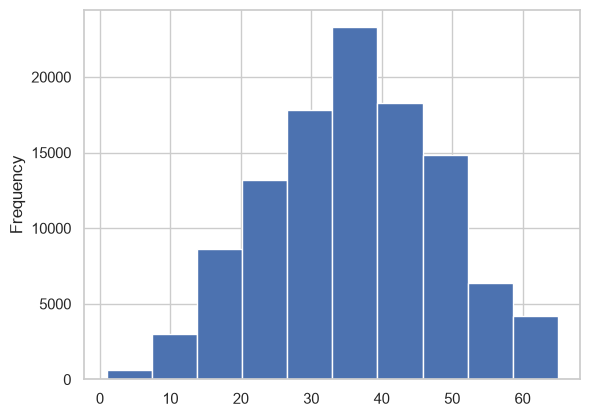

In [228]:
X_train.DTI.plot.hist()

<Axes: ylabel='Frequency'>

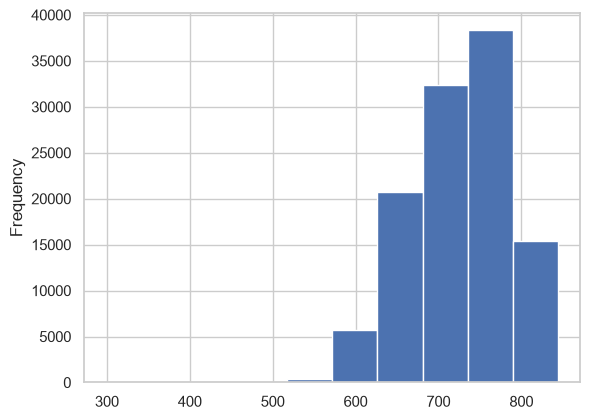

In [229]:
X_train.CREDIT_SCORE.plot.hist()

In [248]:
# 2. Map the true original missingness signatures straight into your current imputed dataframes
X_train_imp['CREDIT_SCORE_IS_MISSING'] = X_train['CREDIT_SCORE'].isna().astype(int)
X_val_imp['CREDIT_SCORE_IS_MISSING']   = X_val['CREDIT_SCORE'].isna().astype(int)
X_test_imp['CREDIT_SCORE_IS_MISSING']  = X_test['CREDIT_SCORE'].isna().astype(int)

X_train_imp['DTI_IS_MISSING'] = X_train['DTI'].isna().astype(int)
X_val_imp['DTI_IS_MISSING']   = X_val['DTI'].isna().astype(int)
X_test_imp['DTI_IS_MISSING']  = X_test['DTI'].isna().astype(int)

print("\n MNAR Indicators successfully attached!")
print(f"Original missing Credit Scores captured in Train: {X_train_imp['CREDIT_SCORE_IS_MISSING'].sum()}")
print(f"Original missing DTI records captured in Train:    {X_train_imp['DTI_IS_MISSING'].sum()}")


 MNAR Indicators successfully attached!
Original missing Credit Scores captured in Train: 94
Original missing DTI records captured in Train:    2783


In [250]:
X_train_imp.DTI_IS_MISSING.value_counts()

DTI_IS_MISSING
0    110316
1      2783
Name: count, dtype: int64

In [251]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler


# 2. DTI: Isolate the financial features needed for KNN distance math
knn_features = ['DTI', 'CREDIT_SCORE', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE']

# 3. Temporarily Standardize features ONLY to calculate accurate KNN distances
scaler = StandardScaler()
X_train_knn_scaled = scaler.fit_transform(X_train_imp[knn_features])
X_val_knn_scaled   = scaler.transform(X_val_imp[knn_features])
X_test_knn_scaled  = scaler.transform(X_test_imp[knn_features])

# 4. Fit the KNN Imputer on the clean, scaled training features
knn_imputer = KNNImputer(n_neighbors=5)
X_train_imputed_knn_scaled = knn_imputer.fit_transform(X_train_knn_scaled)
X_val_imputed_knn_scaled   = knn_imputer.transform(X_val_knn_scaled)
X_test_imputed_knn_scaled  = knn_imputer.transform(X_test_knn_scaled)

# 5. Inverse-transform back to the original raw scale
X_train_imp[knn_features] = scaler.inverse_transform(X_train_imputed_knn_scaled)
X_val_imp[knn_features]   = scaler.inverse_transform(X_val_imputed_knn_scaled)
X_test_imp[knn_features]  = scaler.inverse_transform(X_test_imputed_knn_scaled)

print(" Missing numerical values left:")
print(f"Train: {X_train_imp[knn_features].isna().sum().sum()} | Val: {X_val_imp[knn_features].isna().sum().sum()} | OOT Test: {X_test_imp[knn_features].isna().sum().sum()}")

 Missing numerical values left:
Train: 0 | Val: 0 | OOT Test: 0


In [252]:
# 1. Calculate missing counts and percentages
missing_counts = X_train_imp.isna().sum()
missing_pct = (X_train_imp.isna().sum() / len(X_train)) * 100

# 2. Combine into a scannable summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pct
}).sort_values(by='Missing Count', ascending=False)

# 3. Display only the columns that actually have missing values
print("=== Missing Value Diagnostic Profile ===")
print(missing_summary[missing_summary['Missing Count'] > 0])

=== Missing Value Diagnostic Profile ===
                  Missing Count  Percentage (%)
NUMBER_BORROWERS             42        0.037136
CLTV                         10        0.008842
NUMBER_UNITS                  1        0.000884


In [253]:
X_train_imp.DTI_IS_MISSING.value_counts()

DTI_IS_MISSING
0    110316
1      2783
Name: count, dtype: int64

In [254]:
X_train_imp.shape

(113099, 28)

In [255]:
# Simple median fill for the remaining minor MCAR columns
for col in ['CLTV', 'NUMBER_UNITS']:
    median_val = X_train_imp[col].median()
    X_train_imp[col] = X_train_imp[col].fillna(median_val)
    X_val_imp[col]   = X_val_imp[col].fillna(median_val)
    X_test_imp[col]  = X_test_imp[col].fillna(median_val)

print(f"Total remaining missing values across features: {X_train_imp.isna().sum().sum()}")

Total remaining missing values across features: 42


In [256]:
# Mode imputation for discrete features across all three data firewalls
X_train_imp['NUMBER_BORROWERS'] = X_train_imp['NUMBER_BORROWERS'].fillna(X_train_imp['NUMBER_BORROWERS'].mode()[0])

In [257]:
# 1. Calculate missing counts and percentages
missing_counts = X_train_imp.isna().sum()
missing_pct = (X_train_imp.isna().sum() / len(X_train)) * 100

# 2. Combine into a scannable summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pct
}).sort_values(by='Missing Count', ascending=False)

# 3. Display only the columns that actually have missing values
print("=== Missing Value Diagnostic Profile ===")
print(missing_summary[missing_summary['Missing Count'] > 0])

=== Missing Value Diagnostic Profile ===
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []


All Imputations Done

In [258]:
X_train_imp.columns

Index(['CREDIT_SCORE', 'FIRST_TIME_BUYER', 'MSA', 'MI_PERCENT', 'NUMBER_UNITS',
       'OCCUPANCY_STATUS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV',
       'ORIGINAL_INTEREST_RATE', 'CHANNEL', 'PPM', 'PROPERTY_STATE',
       'PROPERTY_TYPE', 'POSTAL_CODE', 'LOAN_PURPOSE', 'ORIGINAL_LOAN_TERM',
       'NUMBER_BORROWERS', 'SELLER_NAME', 'SERVICER_NAME',
       'RATE_INCREASE_MAGNITUDE', 'CSUSHPISA', 'BRMHELOC01', 'MORTGAGE30US',
       'DRSFRMACBS', 'CREDIT_SCORE_IS_MISSING', 'DTI_IS_MISSING'],
      dtype='str')

## Outlier Handling and Transformation

<Axes: ylabel='Frequency'>

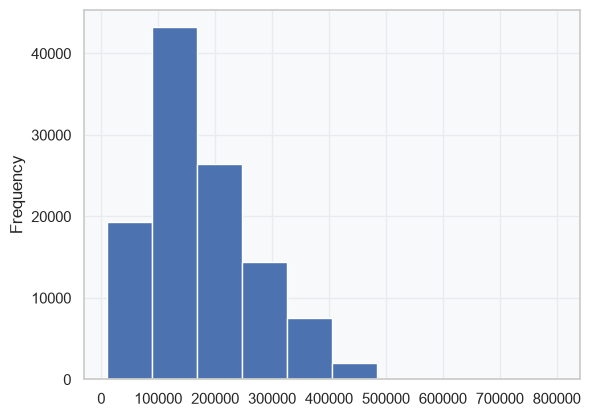

In [264]:
X_train_imp.ORIGINAL_UPB.plot.hist()

<Axes: >

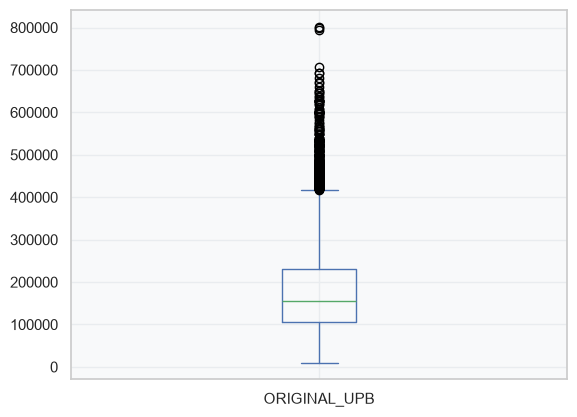

In [265]:
X_train_imp.ORIGINAL_UPB.plot.box()

<Axes: >

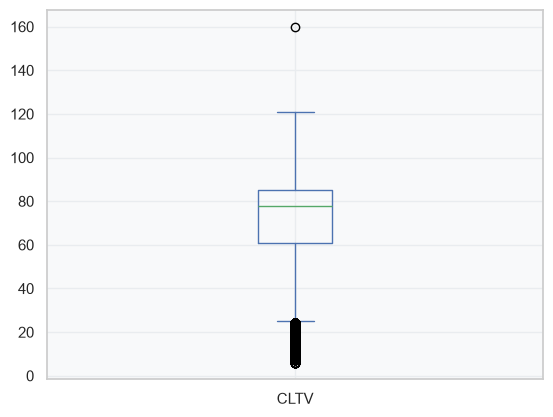

In [266]:
X_train_imp.CLTV.plot.box()

<Axes: ylabel='Frequency'>

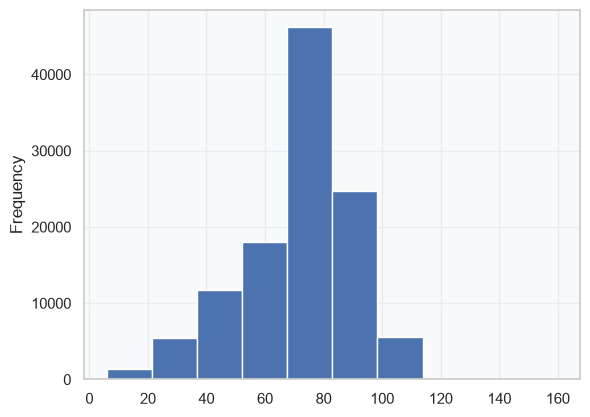

In [267]:
X_train_imp.CLTV.plot.hist()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer

# =====================================================================
# INITIALIZATION: Create clean working copies for the Imputation Pool
# =====================================================================
X_train_imp = X_train.copy()
X_val_imp   = X_val.copy()
X_test_imp  = X_test.copy()

print(" Working matrices initialized safely.")

# =====================================================================
# STEP 1: OUTLIER HANDLING (Winsorization via Percentile Clipping)
# =====================================================================
outlier_cols = [
    'ORIGINAL_UPB', 'CLTV', 'LTV', 'CREDIT_SCORE', 
    'MI_PERCENT', 'ORIGINAL_INTEREST_RATE', 
    'ORIGINAL_LOAN_TERM', 'RATE_INCREASE_MAGNITUDE'
]

print("\n Commencing percentile capping on active continuous features...")

for col in outlier_cols:
    if col in X_train_imp.columns:
        # Derive thresholds strictly from Training distribution to prevent leakage
        lower_bound = X_train_imp[col].quantile(0.01)
        upper_bound = X_train_imp[col].quantile(0.99)
        
        # Hard structural override for non-standard US mortgage terms
        if col == 'ORIGINAL_LOAN_TERM':
            upper_bound = 360.0
            
        # Apply the exact same boundaries across all three data splits
        X_train_imp[col] = np.clip(X_train_imp[col], lower_bound, upper_bound)
        X_val_imp[col]   = np.clip(X_val_imp[col], lower_bound, upper_bound)
        X_test_imp[col]  = np.clip(X_test_imp[col], lower_bound, upper_bound)

print(" Outlier treatment complete! Active distributions stabilized.")

# =====================================================================
# STEP 2: ADVANCED DISTRIBUTION TRANSFORMATIONS (Power & Log Scaling)
# =====================================================================
print("\n🪵 Launching distribution transformations...")

# 1. Box-Cox for strictly positive, heavily right-skewed monetary metrics
boxcox_cols = ['ORIGINAL_UPB']
pt_boxcox = PowerTransformer(method='box-cox', standardize=False)

X_train_imp[boxcox_cols] = pt_boxcox.fit_transform(X_train_imp[boxcox_cols])
X_val_imp[boxcox_cols]   = pt_boxcox.transform(X_val_imp[boxcox_cols])
X_test_imp[boxcox_cols]  = pt_boxcox.transform(X_test_imp[boxcox_cols])

# 2. Simplified log(x + 1) for semicontinuous metrics with structural zeros
log1p_cols = ['MI_PERCENT', 'RATE_INCREASE_MAGNITUDE']

for col in log1p_cols:
    X_train_imp[col] = np.log1p(X_train_imp[col])
    X_val_imp[col]   = np.log1p(X_val_imp[col])
    X_test_imp[col]  = np.log1p(X_test_imp[col])

# Note: LTV, CLTV, DTI, and CREDIT_SCORE bypass this section 
# to keep their natural underwriting shapes and risk cliff thresholds unwarped.

print(" Transformations complete! Zero-inflation handled cleanly via log1p.")
print("\n=== Preprocessing Stage Complete ===")